
===== CELL A — ROOT PORTABLE EXTRACTION + NP↔NI ALIGNMENT =====
User inputs loaded successfully.
SESSION_FOLDER: D:\Kevin\04032026
NI_TTL_FOLDER: G:\Kevin\2026-03-04_08-31-33\Record Node 104\experiment1\recording1\events\NI-DAQmx-103.PXIe-6341\TTL
PROBEA_PATH: G:\Kevin\2026-03-04_08-31-33\Record Node 101\experiment1\recording1\continuous\Neuropix-PXI-100.ProbeA\kilosort4
CAMERA_TTL_PIN: 1
EXPERIMENT_NUMBER: 1
NI_SYNC_BIT: 5
NP_SYNC_BIT: 0

Using experiment folder: G:\Kevin\2026-03-04_08-31-33\Record Node 101\experiment1
Using recording folder: G:\Kevin\2026-03-04_08-31-33\Record Node 101\experiment1\recording1
Analysis folder resolved to: G:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis

===== NP ↔ NI ALIGNMENT (SYNC) =====
NI continuous time range: 12.975 → 2460.251 s
NP continuous time range: 12.782 → 2460.072 s
NI sync pulses (bit 5): 2447

===== AUTO-DETECTING NP TTL FOLDER =====
Found NP TTL folder: G:\Kevin\2026-03-04_08-31-33\Reco

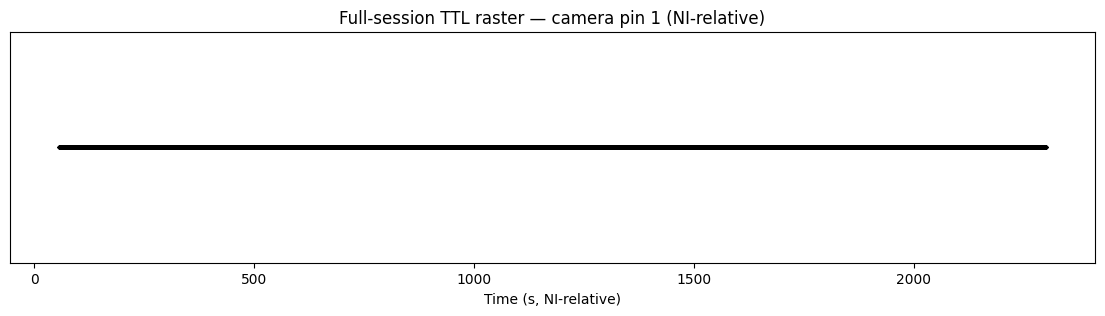


===== TTL BLOCK DETECTOR COMPLETE =====

===== QC CHECK: Firing-rate matrix =====
QC files missing — computing...
Loaded 100 good units.
Found 290 noise units total.
Using 20 sampled noise units.
Saved rate_matrix → G:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis\qc\rate_matrix.npy
Saved noise_rate_matrix → G:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis\qc\noise_rate_matrix.npy

===== QC COMPLETE =====



In [7]:
# ============================================================
# =======================  CELL A  ============================
# ========== ROOT CELL — TTLs + QC + PORTABLE SPIKES =========
# ========== WITH NP ↔ NI CLOCK ALIGNMENT (SYNC) =============
# ============================================================

import os
import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

print("\n===== CELL A — ROOT PORTABLE EXTRACTION + NP↔NI ALIGNMENT =====")

# ------------------------------------------------------------
# USER INPUTS
# ------------------------------------------------------------

SESSION_FOLDER = r"D:\Kevin\04032026"

# NOTE: underscore in date here:
NI_TTL_FOLDER = r"G:\Kevin\2026-03-04_08-31-33\Record Node 104\experiment1\recording1\events\NI-DAQmx-103.PXIe-6341\TTL"
PROBEA_PATH   = r"G:\Kevin\2026-03-04_08-31-33\Record Node 101\experiment1\recording1\continuous\Neuropix-PXI-100.ProbeA\kilosort4"

EXPERIMENT_NUMBER = 1

CAMERA_TTL_PIN = 1
EXPECTED_RATE_HZ = 60
MISSING_TTL_THRESHOLD = 60
MIN_BLOCK_LENGTH = 900

FILENAME_PATTERN = r"frame_(\d+)_cnt_(\d+)\.raw"

# Sync bits
NI_SYNC_BIT = 5   # NI TTL bit carrying 1 Hz sync
NP_SYNC_BIT = 0   # NP TTL bit carrying 1 Hz sync (you just found this)

####################

print("User inputs loaded successfully.")
print(f"SESSION_FOLDER: {SESSION_FOLDER}")
print(f"NI_TTL_FOLDER: {NI_TTL_FOLDER}")
print(f"PROBEA_PATH: {PROBEA_PATH}")
print(f"CAMERA_TTL_PIN: {CAMERA_TTL_PIN}")
print(f"EXPERIMENT_NUMBER: {EXPERIMENT_NUMBER}")
print(f"NI_SYNC_BIT: {NI_SYNC_BIT}")
print(f"NP_SYNC_BIT: {NP_SYNC_BIT}")

# ------------------------------------------------------------
# UNIFIED ANALYSIS FOLDER
# ------------------------------------------------------------

def find_session_root(path):
    path = Path(path).resolve()
    while True:
        if "record node" in path.name.lower():
            return path
        parent = path.parent
        if parent == path:
            raise RuntimeError("Could not find 'Record Node' folder above given path")
        path = parent

def build_analysis_folder(session_root, experiment_number):
    experiment_folders = sorted(
        [f for f in session_root.iterdir()
         if f.is_dir() and f.name.lower().startswith("experiment")],
        key=lambda p: p.name
    )

    if experiment_number < 1 or experiment_number > len(experiment_folders):
        raise RuntimeError(
            f"Experiment {experiment_number} does not exist. "
            f"Found experiments: {[f.name for f in experiment_folders]}"
        )

    experiment_folder = experiment_folders[experiment_number - 1]
    print(f"\nUsing experiment folder: {experiment_folder}")

    recording_folders = sorted(
        [f for f in experiment_folder.iterdir()
         if f.is_dir() and f.name.lower().startswith("recording")],
        key=lambda p: p.name
    )
    if not recording_folders:
        raise RuntimeError("No recording folder found inside experiment folder")

    recording_folder = recording_folders[0]
    print(f"Using recording folder: {recording_folder}")

    session_date_folder = session_root.parent
    session_date = session_date_folder.name
    experiment_name = experiment_folder.name
    recording_name = recording_folder.name

    folder_name = f"{session_date}_{experiment_name}_{recording_name}_analysis"
    analysis_folder = session_root / folder_name
    analysis_folder.mkdir(exist_ok=True)

    print(f"Analysis folder resolved to: {analysis_folder}")

    subfolders = [
        "qc",
        "camera_alignment",
        "dlc_alignment",
        "behavior_ttls",
        "peak_detection",
        "metadata",
        "ttls",
        "spikes"
    ]
    for sf in subfolders:
        (analysis_folder / sf).mkdir(exist_ok=True)

    return analysis_folder

def get_analysis_folder(path_from_any_pipeline, experiment_number):
    session_root = find_session_root(path_from_any_pipeline)
    return build_analysis_folder(session_root, experiment_number)

analysis_folder = get_analysis_folder(PROBEA_PATH, EXPERIMENT_NUMBER)

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def save_incrementing(folder, base_name, array):
    folder = Path(folder)
    folder.mkdir(exist_ok=True)
    path = folder / f"{base_name}.npy"
    if not path.exists():
        np.save(path, array)
        return path
    counter = 1
    while True:
        path = folder / f"{base_name}_{counter}.npy"
        if not path.exists():
            np.save(path, array)
            return path
        counter += 1

def load_latest(folder, base_name):
    folder = Path(folder)
    candidates = list(folder.glob(f"{base_name}*.npy"))
    if not candidates:
        raise FileNotFoundError(f"No files matching {base_name} in {folder}")
    latest = sorted(candidates, key=lambda p: p.stem)[-1]
    return np.load(latest, allow_pickle=True)

def extract_rising_edges(full_words, timestamps, pin):
    mask = 1 << pin
    bit_on = (full_words & mask) > 0
    bit_prev = np.roll(bit_on, 1)
    bit_prev[0] = False
    rising = (~bit_prev) & bit_on
    return timestamps[rising]

# ------------------------------------------------------------
# NP ↔ NI ALIGNMENT (SYNC PULSES + CONTINUOUS)
# ------------------------------------------------------------

print("\n===== NP ↔ NI ALIGNMENT (SYNC) =====")

# --- NI continuous timestamps ---
ni_ttl_folder = Path(NI_TTL_FOLDER)
ni_device_name = ni_ttl_folder.parent.name
recording_root = ni_ttl_folder.parents[2]
ni_cont_folder = recording_root / "continuous" / ni_device_name

ni_cont_timestamps = np.load(ni_cont_folder / "timestamps.npy")
ni_start_cont = float(ni_cont_timestamps[0])
ni_end_cont   = float(ni_cont_timestamps[-1])
print(f"NI continuous time range: {ni_start_cont:.3f} → {ni_end_cont:.3f} s")

# --- NP continuous timestamps ---
probe_cont_folder = Path(PROBEA_PATH).parent
np_cont_timestamps = np.load(probe_cont_folder / "timestamps.npy")
np_start_cont = float(np_cont_timestamps[0])
np_end_cont   = float(np_cont_timestamps[-1])
print(f"NP continuous time range: {np_start_cont:.3f} → {np_end_cont:.3f} s")

# --- NI sync pulses ---
timestamps_ni_ttl = np.load(ni_ttl_folder / "timestamps.npy")
full_words_ni = np.load(ni_ttl_folder / "full_words.npy")
sync_times_ni = extract_rising_edges(full_words_ni, timestamps_ni_ttl, NI_SYNC_BIT)
print(f"NI sync pulses (bit {NI_SYNC_BIT}): {len(sync_times_ni)}")
if len(sync_times_ni) == 0:
    raise RuntimeError("No NI sync pulses detected on specified bit.")

# --- NP sync pulses (AUTO-DETECT NP TTL FOLDER) ---
print("\n===== AUTO-DETECTING NP TTL FOLDER =====")

session_root = find_session_root(PROBEA_PATH)
session_parent = session_root.parent

np_ttl_folder = None

for rn in session_parent.iterdir():
    if rn.is_dir() and rn.name.lower().startswith("record node"):
        events_dir = rn / "experiment1" / "recording1" / "events"
        if not events_dir.exists():
            continue

        for f in events_dir.iterdir():
            if f.is_dir() and "Neuropix" in f.name and "ProbeA" in f.name:
                candidate = f / "TTL"
                if (candidate / "timestamps.npy").exists() and (candidate / "full_words.npy").exists():
                    np_ttl_folder = candidate
                    print(f"Found NP TTL folder: {np_ttl_folder}")
                    break

        if np_ttl_folder is not None:
            break

if np_ttl_folder is None:
    raise RuntimeError("Could not find ANY Neuropix-PXI-XXX.ProbeA/TTL folder in ANY Record Node.")

timestamps_np_ttl = np.load(np_ttl_folder / "timestamps.npy")
full_words_np = np.load(np_ttl_folder / "full_words.npy")

print(f"Loaded NP TTLs from: {np_ttl_folder}")
print(f"NP TTL count: {len(full_words_np)}")

sync_times_np = extract_rising_edges(full_words_np, timestamps_np_ttl, NP_SYNC_BIT)
print(f"NP sync pulses (bit {NP_SYNC_BIT}): {len(sync_times_np)}")
if len(sync_times_np) == 0:
    raise RuntimeError("No NP sync pulses detected on specified bit.")

# --- Trim to common length ---
n_common = min(len(sync_times_np), len(sync_times_ni))
sync_times_np = sync_times_np[:n_common]
sync_times_ni = sync_times_ni[:n_common]
print(f"Using {n_common} pulses for alignment.")

# --- Fit linear mapping ---
A = np.vstack([sync_times_np, np.ones_like(sync_times_np)]).T
a, b = np.linalg.lstsq(A, sync_times_ni, rcond=None)[0]

pred_ni = a * sync_times_np + b
residuals = sync_times_ni - pred_ni

print("\n===== NP → NI LINEAR MAPPING =====")
print(f"t_NI ≈ {a:.9f} * t_NP + {b:.6f}")
print(f"Offset (b): {b:.6f} s")
print(f"Scale  (a): {a:.9f}")
print("\nResiduals (NI - predicted NI):")
print(f"  mean: {np.mean(residuals):.6f} s")
print(f"  std:  {np.std(residuals):.6f} s")
print(f"  max:  {np.max(np.abs(residuals)):.6f} s")

# --- Save alignment metadata ---
align_meta = {
    "np_to_ni_a": float(a),
    "np_to_ni_b": float(b),
    "n_pulses_used": int(n_common),
    "residual_mean": float(np.mean(residuals)),
    "residual_std": float(np.std(residuals)),
    "residual_max_abs": float(np.max(np.abs(residuals))),
    "ni_sync_bit": int(NI_SYNC_BIT),
    "np_sync_bit": int(NP_SYNC_BIT),
    "ni_cont_start": ni_start_cont,
    "ni_cont_end": ni_end_cont,
    "np_cont_start": np_start_cont,
    "np_cont_end": np_end_cont,
}
meta_align_path = analysis_folder / "metadata" / "np_ni_alignment.json"
with open(meta_align_path, "w") as f:
    json.dump(align_meta, f, indent=2)
print(f"\nSaved NP↔NI alignment metadata → {meta_align_path}")

# Define canonical timebase
t0_ni = ni_start_cont
print(f"\nCanonical timebase: NI-relative (t0 = {t0_ni:.6f} s)")

# ------------------------------------------------------------
# LOAD NI-DAQ TTL STREAM (AND SHIFT TO NI-RELATIVE TIME)
# ------------------------------------------------------------

timestamps_ni = timestamps_ni_ttl
full_words_ni = full_words_ni

print(f"\nLoaded NI-DAQ TTL data: {len(full_words_ni)} samples")

timestamps_ni_rel = timestamps_ni - t0_ni

# ------------------------------------------------------------
# EXTRACT TTLs FOR ALL PINS (0–7) IN NI-RELATIVE TIME
# ------------------------------------------------------------

ttls_dir = analysis_folder / "ttls"
all_pin_ttls = {}

for pin in range(8):
    ttls_abs = extract_rising_edges(full_words_ni, timestamps_ni, pin)
    ttls_rel = ttls_abs - t0_ni
    all_pin_ttls[pin] = ttls_rel
    save_incrementing(ttls_dir, f"TTL_Pin_{pin}", ttls_rel)
    print(f"Saved {len(ttls_rel)} TTLs for pin {pin} (NI-relative)")

ni_meta = {
    "pins": list(range(8)),
    "camera_ttl_pin_used_for_blocks": int(CAMERA_TTL_PIN),
    "ni_start_time_abs": float(ni_start_cont),
    "ni_end_time_abs": float(ni_end_cont),
    "ni_start_time_rel": 0.0,
    "ni_end_time_rel": float(ni_end_cont - t0_ni),
    "expected_rate_hz": EXPECTED_RATE_HZ,
    "missing_ttl_threshold": MISSING_TTL_THRESHOLD,
    "min_block_length": MIN_BLOCK_LENGTH,
}
with open(analysis_folder / "metadata" / "ttl_metadata.json", "w") as f:
    json.dump(ni_meta, f, indent=2)

print("Saved TTL metadata (NI-relative).")

# ------------------------------------------------------------
# TTL BLOCK DETECTION (CAMERA PIN) IN NI-RELATIVE TIME
# ------------------------------------------------------------

print("\n===== TTL BLOCK DETECTOR =====")

rising_times = all_pin_ttls[CAMERA_TTL_PIN]
print(f"Detected {len(rising_times)} rising edges on camera pin {CAMERA_TTL_PIN}")

ipi = np.diff(rising_times)
expected_ipi = 1.0 / EXPECTED_RATE_HZ
gap_threshold = expected_ipi * MISSING_TTL_THRESHOLD

gap_mask = ipi > gap_threshold
gap_indices = np.where(gap_mask)[0]

block_starts = np.insert(gap_indices + 1, 0, 0)
block_ends   = np.append(gap_indices, len(rising_times) - 1)

ttl_blocks = []
block_info = []

for b_idx, (start, end) in enumerate(zip(block_starts, block_ends)):
    block_len = end - start + 1
    if block_len < MIN_BLOCK_LENGTH:
        print(f"Skipping block {b_idx} (too short: {block_len})")
        continue

    block_times = rising_times[start:end+1]
    ttl_blocks.append(block_times)

    info = {
        "block_index": b_idx,
        "ttl_start_index": int(start),
        "ttl_end_index": int(end),
        "n_ttls": int(block_len),
        "start_time_sec": float(block_times[0]),
        "end_time_sec": float(block_times[-1]),
        "duration_sec": float(block_times[-1] - block_times[0]),
        "gap_threshold_sec": float(gap_threshold),
        "camera_ttl_pin": int(CAMERA_TTL_PIN),
    }
    block_info.append(info)

    print(f"\nBlock {b_idx}:")
    print(f"  TTLs: {block_len}")
    print(f"  Start (NI-rel): {block_times[0]:.3f}s")
    print(f"  End   (NI-rel): {block_times[-1]:.3f}s")

with open(analysis_folder / "metadata" / "block_info.json", "w") as f:
    json.dump(block_info, f, indent=2)

cam_align_dir = analysis_folder / "camera_alignment"
for b_idx, block_times in enumerate(ttl_blocks):
    save_incrementing(cam_align_dir, f"ttl_times_block{b_idx}", block_times)

plt.figure(figsize=(14, 3))
plt.scatter(rising_times, np.zeros_like(rising_times), s=2, c='k')
plt.title(f"Full-session TTL raster — camera pin {CAMERA_TTL_PIN} (NI-relative)")
plt.xlabel("Time (s, NI-relative)")
plt.yticks([])
plt.show()

print("\n===== TTL BLOCK DETECTOR COMPLETE =====")

# ------------------------------------------------------------
# QC COMPUTATION (SPIKES + RATE MATRIX + NOISE UNITS)
# ------------------------------------------------------------

print("\n===== QC CHECK: Firing-rate matrix =====")

qc_dir = analysis_folder / "qc"
spikes_dir = analysis_folder / "spikes"

rate_path = qc_dir / "rate_matrix.npy"
good_units_path = qc_dir / "good_units.npy"
centers_path = qc_dir / "centers.npy"
duration_path = qc_dir / "recording_duration.json"
noise_units_path = qc_dir / "noise_units.npy"
noise_rate_path = qc_dir / "noise_rate_matrix.npy"

if rate_path.exists() and good_units_path.exists() and centers_path.exists() and duration_path.exists() and noise_units_path.exists() and noise_rate_path.exists():
    print("QC files already exist — skipping computation.")
else:
    print("QC files missing — computing...")

    spike_times_np = np.load(Path(PROBEA_PATH) / "spike_times.npy") / 30000.0
    spike_clusters = np.load(Path(PROBEA_PATH) / "spike_clusters.npy")

    spike_times_ni = a * spike_times_np + b
    spike_times_rel = spike_times_ni - t0_ni

    df_info = pd.read_csv(Path(PROBEA_PATH) / "cluster_info.tsv", sep="\t")
    cluster_id_col = "id"
    group_col = "group"

    good_units = df_info[df_info[group_col] == "good"][cluster_id_col].values
    np.save(good_units_path, good_units)
    print(f"Loaded {len(good_units)} good units.")

    for unit in good_units:
        unit_spikes = spike_times_rel[spike_clusters == unit]
        np.save(spikes_dir / f"unit_{unit}.npy", unit_spikes)

    noise_units = df_info[df_info[group_col] == "noise"][cluster_id_col].values
    print(f"Found {len(noise_units)} noise units total.")

    np.random.seed(0)
    if len(noise_units) > 20:
        sampled_noise_units = np.random.choice(noise_units, size=20, replace=False)
    else:
        sampled_noise_units = noise_units

    sampled_noise_units = np.array(sampled_noise_units)
    np.save(noise_units_path, sampled_noise_units)
    print(f"Using {len(sampled_noise_units)} sampled noise units.")

    for unit in sampled_noise_units:
        unit_spikes = spike_times_rel[spike_clusters == unit]
        np.save(spikes_dir / f"noise_unit_{unit}.npy", unit_spikes)

    recording_duration_rel = float(spike_times_rel.max())
    bin_size = 0.02
    bins = np.arange(0, recording_duration_rel + bin_size, bin_size)
    centers = bins[:-1] + bin_size/2

    np.save(centers_path, centers)
    with open(duration_path, "w") as f:
        json.dump({"recording_duration": recording_duration_rel}, f)

    rate_matrix = np.zeros((len(good_units), len(centers)), float)
    for i, unit in enumerate(good_units):
        unit_spikes = spike_times_rel[spike_clusters == unit]
        hist, _ = np.histogram(unit_spikes, bins=bins)
        rate_matrix[i, :] = gaussian_filter1d(hist.astype(float), sigma=2)

    np.save(rate_path, rate_matrix)
    print(f"Saved rate_matrix → {rate_path}")

    noise_rate_matrix = np.zeros((len(sampled_noise_units), len(centers)), float)
    for i, unit in enumerate(sampled_noise_units):
        unit_spikes = spike_times_rel[spike_clusters == unit]
        hist, _ = np.histogram(unit_spikes, bins=bins)
        noise_rate_matrix[i, :] = gaussian_filter1d(hist.astype(float), sigma=2)

    np.save(noise_rate_path, noise_rate_matrix)
    print(f"Saved noise_rate_matrix → {noise_rate_path}")

print("\n===== QC COMPLETE =====\n")



===== CELL B — TTL BLOCK DETECTOR =====
Detected 134517 rising edges on camera pin 1

Detected 1 TTL blocks (before filtering)

Block 0:
  TTLs: 134517
  Start time: 56.948s
  End time:   2299.994s
  Duration:   2243.046s

Saved block_info.json → G:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis\metadata\block_info.json
Saved TTL block 0 → G:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis\camera_alignment\ttl_times_block0_1.npy


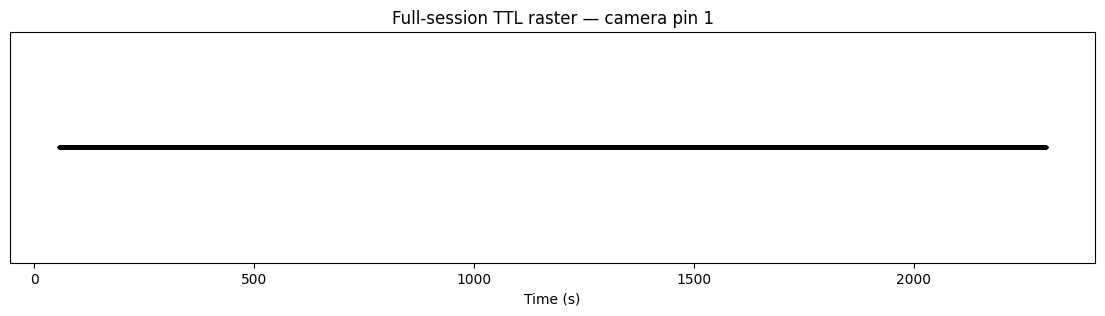

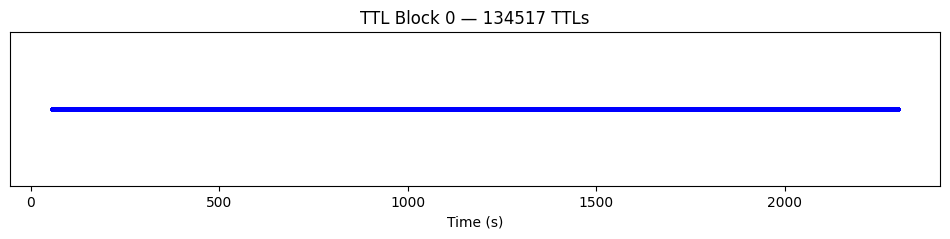


===== TTL BLOCK DETECTOR COMPLETE =====



In [8]:
# ============================================================
# CELL B — TTL BLOCK DETECTOR (CAMERA PIN)
# ============================================================

print("\n===== CELL B — TTL BLOCK DETECTOR =====")

# ------------------------------------------------------------
# SAFETY CHECKS
# ------------------------------------------------------------
required_vars = ["analysis_folder", "all_pin_ttls", "CAMERA_TTL_PIN",
                 "EXPECTED_RATE_HZ", "MISSING_TTL_THRESHOLD", "MIN_BLOCK_LENGTH"]
for v in required_vars:
    if v not in globals():
        raise RuntimeError(f"Variable '{v}' is missing. Run CELL A first.")

# ------------------------------------------------------------
# LOAD TTLs FOR CAMERA PIN
# ------------------------------------------------------------
rising_times = all_pin_ttls[CAMERA_TTL_PIN]
print(f"Detected {len(rising_times)} rising edges on camera pin {CAMERA_TTL_PIN}")

ipi = np.diff(rising_times)
expected_ipi = 1.0 / EXPECTED_RATE_HZ
gap_threshold = expected_ipi * MISSING_TTL_THRESHOLD

gap_mask = ipi > gap_threshold
gap_indices = np.where(gap_mask)[0]

block_starts = np.insert(gap_indices + 1, 0, 0)
block_ends   = np.append(gap_indices, len(rising_times) - 1)

print(f"\nDetected {len(block_starts)} TTL blocks (before filtering)")

ttl_blocks = []
block_info = []

# ------------------------------------------------------------
# BLOCK DETECTION LOOP
# ------------------------------------------------------------
for b, (start, end) in enumerate(zip(block_starts, block_ends)):
    block_len = end - start + 1

    if block_len < MIN_BLOCK_LENGTH:
        print(f"Skipping block {b} (too short: {block_len} TTLs)")
        continue

    block_times = rising_times[start:end+1]
    ttl_blocks.append(block_times)

    info = {
        "block_index": b,
        "ttl_start_index": int(start),
        "ttl_end_index": int(end),
        "n_ttls": int(block_len),
        "start_time_sec": float(block_times[0]),
        "end_time_sec": float(block_times[-1]),
        "duration_sec": float(block_times[-1] - block_times[0]),
        "gap_threshold_sec": float(gap_threshold),
        "camera_ttl_pin": int(CAMERA_TTL_PIN),
    }
    block_info.append(info)

    print(f"\nBlock {b}:")
    print(f"  TTLs: {block_len}")
    print(f"  Start time: {block_times[0]:.3f}s")
    print(f"  End time:   {block_times[-1]:.3f}s")
    print(f"  Duration:   {block_times[-1] - block_times[0]:.3f}s")

# ------------------------------------------------------------
# SAVE BLOCK METADATA
# ------------------------------------------------------------
metadata_path = analysis_folder / "metadata" / "block_info.json"
with open(metadata_path, "w") as f:
    json.dump(block_info, f, indent=2)

print(f"\nSaved block_info.json → {metadata_path}")

# ------------------------------------------------------------
# SAVE TTL BLOCKS (AUTO-INCREMENT)
# ------------------------------------------------------------
ttl_dir = analysis_folder / "camera_alignment"
ttl_dir.mkdir(exist_ok=True)

for b, block_times in enumerate(ttl_blocks):
    out_path = save_incrementing(ttl_dir, f"ttl_times_block{b}", block_times)
    print(f"Saved TTL block {b} → {out_path}")

# ------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------
plt.figure(figsize=(14, 3))
plt.scatter(rising_times, np.zeros_like(rising_times), s=2, c='k')
plt.title(f"Full-session TTL raster — camera pin {CAMERA_TTL_PIN}")
plt.xlabel("Time (s)")
plt.yticks([])
plt.show()

for b, block_times in enumerate(ttl_blocks):
    plt.figure(figsize=(12, 2))
    plt.scatter(block_times, np.zeros_like(block_times), s=3, c='blue')
    plt.title(f"TTL Block {b} — {len(block_times)} TTLs")
    plt.xlabel("Time (s)")
    plt.yticks([])
    plt.show()

print("\n===== TTL BLOCK DETECTOR COMPLETE =====\n")


In [10]:
# ============================================================
# =============== CELL C — CAMERA MAPPING ====================
# ============================================================

import os
import json

print("\n===== CAMERA FOLDER MAPPING =====")

# ------------------------------------------------------------
# SAFETY CHECKS
# ------------------------------------------------------------
required_vars = ["analysis_folder", "ttl_blocks"]
for v in required_vars:
    if v not in globals():
        raise RuntimeError(f"Variable '{v}' is missing. Run previous cells first.")

print(f"Detected {len(ttl_blocks)} TTL blocks.")
print("Define CAM_FOLDERS mapping manually.\n")

# ------------------------------------------------------------
# MANUAL MAPPING: block index → camera folder
# ------------------------------------------------------------
CAM_FOLDERS = {
    0: r"D:\Kevin\04032026\04032026-1\cam2",   # <--- Kevin edits this #########################################################################################################################################################
}
# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------
if len(CAM_FOLDERS) != len(ttl_blocks):
    raise ValueError(
        f"❌ CAM_FOLDERS count mismatch: "
        f"{len(CAM_FOLDERS)} provided vs {len(ttl_blocks)} TTL blocks."
    )

expected_keys = set(range(len(ttl_blocks)))
if set(CAM_FOLDERS.keys()) != expected_keys:
    raise ValueError(
        f"❌ CAM_FOLDERS keys must be {expected_keys}, "
        f"but got {set(CAM_FOLDERS.keys())}"
    )

for b, path in CAM_FOLDERS.items():
    if not os.path.isdir(path):
        raise FileNotFoundError(f"❌ Camera folder for block {b} not found:\n{path}")

# ------------------------------------------------------------
# SUCCESS PRINT
# ------------------------------------------------------------
print("\n✅ Camera folders mapped successfully:")
for b, path in CAM_FOLDERS.items():
    print(f"  Block {b} → {path}")

# ------------------------------------------------------------
# SAVE CAMERA MAPPING
# ------------------------------------------------------------
camera_map_path = analysis_folder / "metadata" / "camera_mapping.json"
with open(camera_map_path, "w") as f:
    json.dump(CAM_FOLDERS, f, indent=2)

print(f"\nSaved camera mapping → {camera_map_path}")
print("\n===== CAMERA MAPPING COMPLETE =====\n")



===== CAMERA FOLDER MAPPING =====
Detected 1 TTL blocks.
Define CAM_FOLDERS mapping manually.


✅ Camera folders mapped successfully:
  Block 0 → D:\Kevin\04032026\04032026-1\cam2

Saved camera mapping → G:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis\metadata\camera_mapping.json

===== CAMERA MAPPING COMPLETE =====



In [11]:
# ============================================================
# =============== CELL D — DLC OUTPUT MAPPING ================
# ============================================================

import os
import json

print("\n===== DLC OUTPUT MAPPING =====")

# ------------------------------------------------------------
# SAFETY CHECKS
# ------------------------------------------------------------
required_vars = ["analysis_folder", "ttl_blocks"]
for v in required_vars:
    if v not in globals():
        raise RuntimeError(f"Variable '{v}' is missing. Run previous cells first.")

print(f"Detected {len(ttl_blocks)} TTL blocks.")
print("Define DLC_OUTPUTS mapping manually.\n")

# ------------------------------------------------------------
# MANUAL MAPPING: block index → DLC output file
# ------------------------------------------------------------
DLC_OUTPUTS = {
    0: r"F:\Mouse1_030426-Kpk\03042026_Cam2-Kevin-2026-05-05\videos\04032026-1_cam2DLC_Resnet50_03042026_Cam2May5shuffle2_snapshot_best-40.h5",  #####################################################################################################
}

# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------
if len(DLC_OUTPUTS) != len(ttl_blocks):
    raise ValueError(
        f"❌ DLC_OUTPUTS count mismatch: "
        f"{len(DLC_OUTPUTS)} provided vs {len(ttl_blocks)} TTL blocks."
    )

expected_keys = set(range(len(ttl_blocks)))
if set(DLC_OUTPUTS.keys()) != expected_keys:
    raise ValueError(
        f"❌ DLC_OUTPUTS keys must be {expected_keys}, "
        f"but got {set(DLC_OUTPUTS.keys())}"
    )

for b, path in DLC_OUTPUTS.items():
    if not os.path.isfile(path):
        raise FileNotFoundError(f"❌ DLC file for block {b} not found:\n{path}")

# ------------------------------------------------------------
# SUCCESS PRINT
# ------------------------------------------------------------
print("\n✅ DLC outputs mapped successfully:")
for b, path in DLC_OUTPUTS.items():
    print(f"  Block {b} → {path}")

# ------------------------------------------------------------
# SAVE DLC MAPPING
# ------------------------------------------------------------
dlc_map_path = analysis_folder / "metadata" / "dlc_mapping.json"
with open(dlc_map_path, "w") as f:
    json.dump(DLC_OUTPUTS, f, indent=2)

print(f"\nSaved DLC mapping → {dlc_map_path}")
print("\n===== DLC OUTPUT MAPPING COMPLETE =====\n")



===== DLC OUTPUT MAPPING =====
Detected 1 TTL blocks.
Define DLC_OUTPUTS mapping manually.


✅ DLC outputs mapped successfully:
  Block 0 → F:\Mouse1_030426-Kpk\03042026_Cam2-Kevin-2026-05-05\videos\04032026-1_cam2DLC_Resnet50_03042026_Cam2May5shuffle2_snapshot_best-40.h5

Saved DLC mapping → G:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis\metadata\dlc_mapping.json

===== DLC OUTPUT MAPPING COMPLETE =====



In [12]:
# ============================================================
# =============== CELL E — BUILD SESSION OBJECT ==============
# ============================================================

import json

print("\n===== BUILDING SESSION OBJECT =====")

# ------------------------------------------------------------
# SAFETY CHECKS
# ------------------------------------------------------------
required_vars = ["analysis_folder", "ttl_blocks", "CAM_FOLDERS", "DLC_OUTPUTS"]
for v in required_vars:
    if v not in globals():
        raise RuntimeError(f"Variable '{v}' is missing. Run previous cells first.")

if len(CAM_FOLDERS) != len(ttl_blocks):
    raise ValueError("❌ CAM_FOLDERS count mismatch with TTL blocks.")

if len(DLC_OUTPUTS) != len(ttl_blocks):
    raise ValueError("❌ DLC_OUTPUTS count mismatch with TTL blocks.")

# ------------------------------------------------------------
# BUILD SESSION OBJECT
# ------------------------------------------------------------
session = {"blocks": []}

for block_index, ttl_times_block in enumerate(ttl_blocks):

    block = {
        "block_index": block_index,

        # TTLs (portable)
        "ttl_times": ttl_times_block.tolist(),

        # camera folder (only needed on camera workstation)
        "cam_folder": CAM_FOLDERS[block_index],

        # DLC path (only needed for DLC alignment)
        "dlc_path": DLC_OUTPUTS[block_index],

        # portable output paths (always inside unified analysis folder)
        "aligned_frames_path": str(
            analysis_folder / "camera_alignment" / f"aligned_frames_block{block_index}.npy"
        ),
        "dlc_aligned_path": str(
            analysis_folder / "dlc_alignment" / f"dlc_aligned_block{block_index}.npy"
        ),
    }

    session["blocks"].append(block)

# ------------------------------------------------------------
# SAVE SESSION METADATA
# ------------------------------------------------------------
session_path = analysis_folder / "metadata" / "session.json"
with open(session_path, "w") as f:
    json.dump(session, f, indent=2)

print(f"\nSaved session metadata → {session_path}")

# ------------------------------------------------------------
# PRINT SUMMARY
# ------------------------------------------------------------
print("Session object contains:")
for b in session["blocks"]:
    print(f"  Block {b['block_index']} | TTLs: {len(b['ttl_times'])}")

print("\n===== SESSION OBJECT COMPLETE =====\n")



===== BUILDING SESSION OBJECT =====

Saved session metadata → G:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis\metadata\session.json
Session object contains:
  Block 0 | TTLs: 134517

===== SESSION OBJECT COMPLETE =====



In [13]:
# ============================================================
# ========== CELL G — FRAME ALIGNMENT FOR ALL BLOCKS ==========
# ============================================================

import os
import re
import numpy as np
from pathlib import Path

print("\n===== FRAME ALIGNMENT FOR ALL BLOCKS =====")

# ------------------------------------------------------------
# SAFETY CHECKS
# ------------------------------------------------------------
required_vars = ["session", "analysis_folder", "FILENAME_PATTERN"]
for v in required_vars:
    if v not in globals():
        raise RuntimeError(f"Variable '{v}' is missing. Run previous cells first.")

PATTERN = re.compile(FILENAME_PATTERN)

# ------------------------------------------------------------
# PROCESS EACH BLOCK
# ------------------------------------------------------------
for block_index, block in enumerate(session["blocks"]):

    print(f"\n==============================")
    print(f"Processing block {block_index}")
    print("==============================")

    ttl_times_block = np.array(block["ttl_times"])
    CAM_FOLDER = block["cam_folder"]
    TTL_COUNT = len(ttl_times_block)

    print(f"TTL pulses in block: {TTL_COUNT}")
    print(f"Camera folder: {CAM_FOLDER}")

    # --------------------------------------------------------
    # LOAD CAMERA FRAME FILENAMES
    # --------------------------------------------------------
    entries = []

    for fname in os.listdir(CAM_FOLDER):
        m = PATTERN.match(fname)
        if m:
            frame_idx = int(m.group(1))
            counter   = int(m.group(2))
            entries.append((frame_idx, counter, fname))

    if not entries:
        raise RuntimeError(f"No valid frame files found in {CAM_FOLDER}")

    # Sort by chunk counter (camera truth)
    entries.sort(key=lambda x: x[1])

    frame_indices = np.array([e[0] for e in entries])
    counters      = np.array([e[1] for e in entries])
    filenames     = [e[2] for e in entries]

    print(f"Loaded {len(entries)} frames from camera folder")

    # --------------------------------------------------------
    # FRAME INTEGRITY CHECK
    # --------------------------------------------------------
    print("\n===== FRAME INTEGRITY CHECK =====")

    missing_frame_idx_total = 0
    missing_counter_total   = 0
    problems = []

    last_frame = None
    last_counter = None

    for frame_idx, counter, fname in entries:
        if last_frame is not None:

            expected_frame = last_frame + 1
            if frame_idx != expected_frame:
                gap = frame_idx - expected_frame
                missing_frame_idx_total += gap
                problems.append(
                    f"FRAME INDEX GAP: {last_frame} → {frame_idx} (missing {gap})"
                )

            expected_counter = last_counter + 1
            if counter != expected_counter:
                gap = counter - expected_counter
                missing_counter_total += gap
                problems.append(
                    f"CHUNK COUNTER GAP: {last_counter} → {counter} "
                    f"(missing {gap}) at frame {frame_idx} ({fname})"
                )

        last_frame = frame_idx
        last_counter = counter

    print(f"Total saved frames: {len(entries)}")
    print(f"Missing by frame index: {missing_frame_idx_total}")
    print(f"Missing by chunk counter: {missing_counter_total}")

    if problems:
        print("\n⚠️  PROBLEMS DETECTED:")
        for p in problems:
            print(" -", p)
    else:
        print("\n✅ No discrepancies detected.")

    # --------------------------------------------------------
    # TTL → FRAME ALIGNMENT
    # --------------------------------------------------------
    print("\n===== BUILDING TTL-ALIGNED TIMELINE =====")

    aligned_frames = [None] * TTL_COUNT
    counter_to_file = {c: f for (_, c, f) in entries}
    first_counter = counters[0]

    for ttl_idx in range(TTL_COUNT):
        counter_value = first_counter + ttl_idx
        aligned_frames[ttl_idx] = counter_to_file.get(counter_value, None)

    missing = sum(f is None for f in aligned_frames)
    print(f"Missing frames inserted: {missing}")

    # --------------------------------------------------------
    # SAVE OUTPUT
    # --------------------------------------------------------
    out_path = Path(block["aligned_frames_path"])
    np.save(out_path, aligned_frames)

    print(f"Saved aligned_frames_block{block_index}.npy → {out_path}")

print("\n===== ALL BLOCKS FRAME ALIGNMENT COMPLETE =====\n")



===== FRAME ALIGNMENT FOR ALL BLOCKS =====

Processing block 0
TTL pulses in block: 134517
Camera folder: D:\Kevin\04032026\04032026-1\cam2
Loaded 120268 frames from camera folder

===== FRAME INTEGRITY CHECK =====
Total saved frames: 120268
Missing by frame index: 0
Missing by chunk counter: 13648

⚠️  PROBLEMS DETECTED:
 - CHUNK COUNTER GAP: 421900 → 422395 (missing 494) at frame 27621 (frame_027621_cnt_422395.raw)
 - CHUNK COUNTER GAP: 425067 → 425464 (missing 396) at frame 30294 (frame_030294_cnt_425464.raw)
 - CHUNK COUNTER GAP: 428487 → 428959 (missing 471) at frame 33318 (frame_033318_cnt_428959.raw)
 - CHUNK COUNTER GAP: 431990 → 432454 (missing 463) at frame 36350 (frame_036350_cnt_432454.raw)
 - CHUNK COUNTER GAP: 435408 → 435890 (missing 481) at frame 39305 (frame_039305_cnt_435890.raw)
 - CHUNK COUNTER GAP: 440572 → 441040 (missing 467) at frame 43988 (frame_043988_cnt_441040.raw)
 - CHUNK COUNTER GAP: 443784 → 444259 (missing 474) at frame 46733 (frame_046733_cnt_444259.r


===== Multi-Block Timeline Visualization =====
Full-session TTL pulses on pin 1: 134517

--- Block 0 ---
TTL pulses: 134517
Aligned frames loaded from: G:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis\camera_alignment\aligned_frames_block0.npy
Start: 56.948 s
End:   2299.994 s

Collected all block timelines.


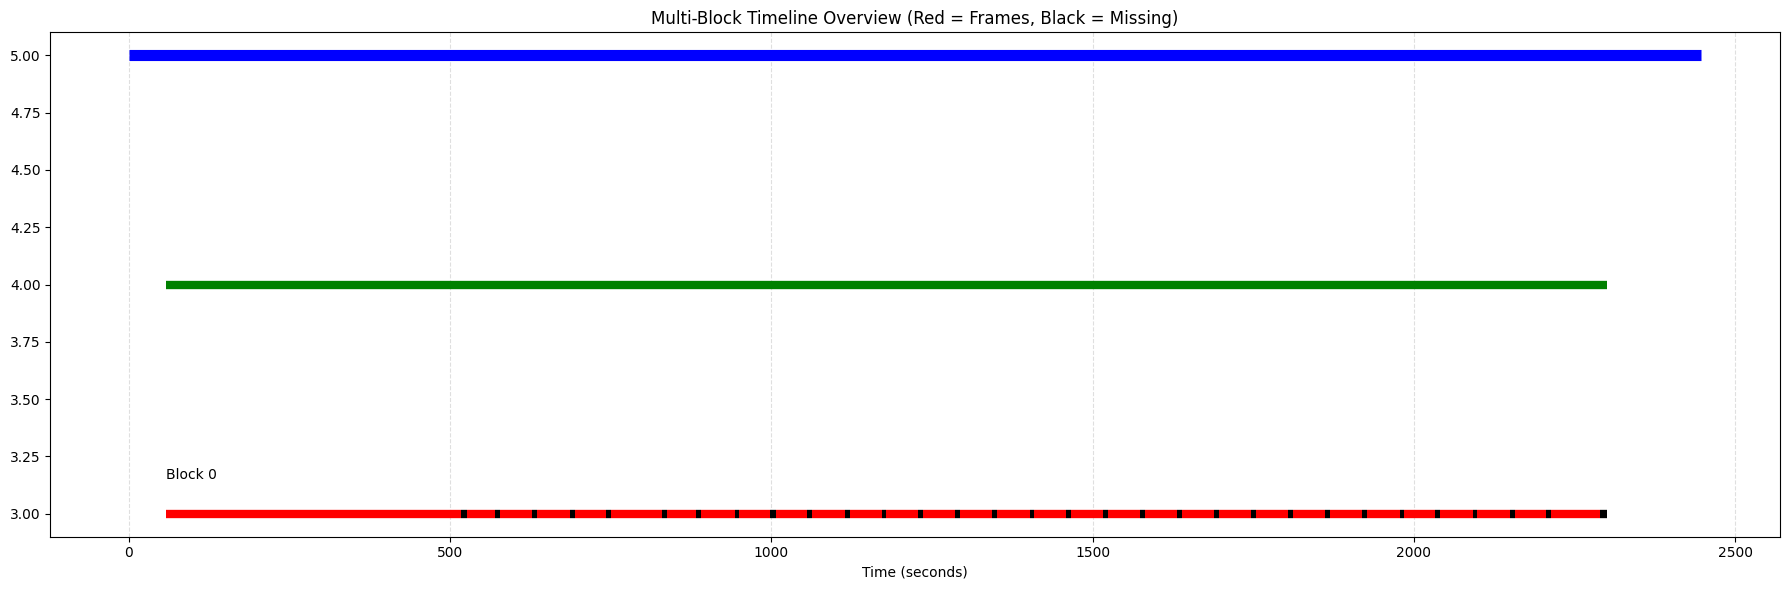


===== MULTI-BLOCK TIMELINE VISUALIZATION COMPLETE =====

Saved timeline figure → G:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis\camera_alignment\timeline_overview_pin1.png


In [14]:
# ============================================================
# ========== CELL H — MULTI-BLOCK TIMELINE VISUALIZATION =====
# ============================================================

import os
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("\n===== Multi-Block Timeline Visualization =====")

# ------------------------------------------------------------
# SAFETY CHECKS
# ------------------------------------------------------------
required_vars = ["analysis_folder", "session"]
for v in required_vars:
    if v not in globals():
        raise RuntimeError(f"Variable '{v}' is missing. Run previous cells first.")

# ------------------------------------------------------------
# USER INPUT: which camera TTL pin to visualize
# ------------------------------------------------------------
CAMERA_TTL_PIN = 1   ################################################################################################################################################

# ------------------------------------------------------------
# 1. Load full-session TTLs for that camera pin (PORTABLE)
# ------------------------------------------------------------
ttls_dir = analysis_folder / "ttls"
ttl_times_full = np.load(ttls_dir / f"TTL_Pin_{CAMERA_TTL_PIN}.npy")

print(f"Full-session TTL pulses on pin {CAMERA_TTL_PIN}: {len(ttl_times_full)}")

meta_path = analysis_folder / "metadata" / "ttl_metadata.json"
with open(meta_path, "r") as f:
    ttl_meta = json.load(f)

ni_start = ttl_meta["ni_start_time_rel"]   # always 0.0
ni_end   = ttl_meta["ni_end_time_rel"]

# ------------------------------------------------------------
# 2. Collect block timelines
# ------------------------------------------------------------
block_segments = []

for block_index, block in enumerate(session["blocks"]):

    ttl_times_block = np.array(block["ttl_times"])

    aligned_frames_path = Path(block["aligned_frames_path"])
    if not aligned_frames_path.exists():
        raise FileNotFoundError(f"Aligned frames file missing:\n{aligned_frames_path}")

    aligned_frames = np.load(aligned_frames_path, allow_pickle=True)

    print(f"\n--- Block {block_index} ---")
    print(f"TTL pulses: {len(ttl_times_block)}")
    print(f"Aligned frames loaded from: {aligned_frames_path}")

    block_start = ttl_times_block[0]
    block_end   = ttl_times_block[-1]

    print(f"Start: {block_start:.3f} s")
    print(f"End:   {block_end:.3f} s")

    block_segments.append({
        "index": block_index,
        "ttl_times": ttl_times_block,
        "aligned_frames": aligned_frames,
        "start": block_start,
        "end": block_end,
    })

print("\nCollected all block timelines.")

# ------------------------------------------------------------
# 3. Plot everything on one figure
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(18, 6))

y_ni = 5
y_ttl_base = 4
y_frames_base = 3

ax.hlines(y_ni, ni_start, ni_end, color='blue', linewidth=8, label="NI-DAQ Recording")

for seg in block_segments:

    b = seg["index"]
    ttl_times_block = seg["ttl_times"]
    aligned_frames = seg["aligned_frames"]

    y_ttl = y_ttl_base - b * 0.6
    y_frames = y_frames_base - b * 0.6

    ax.hlines(y_ttl, seg["start"], seg["end"], color='green', linewidth=6)

    TTL_COUNT = len(ttl_times_block)
    for i, f in enumerate(aligned_frames):
        t0 = ttl_times_block[i]
        if i < TTL_COUNT - 1:
            t1 = ttl_times_block[i+1]
        else:
            t1 = t0 + (ttl_times_block[-1] - ttl_times_block[-2])

        color = 'red' if f is not None else 'black'
        ax.hlines(y_frames, t0, t1, color=color, linewidth=6)

    ax.text(seg["start"], y_frames + 0.15, f"Block {b}", fontsize=10)

ax.set_xlabel("Time (seconds)")
ax.set_title("Multi-Block Timeline Overview (Red = Frames, Black = Missing)")
ax.grid(True, axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print("\n===== MULTI-BLOCK TIMELINE VISUALIZATION COMPLETE =====\n")

# ------------------------------------------------------------
# 4. SAVE FIGURE TO ANALYSIS FOLDER (AUTO-INCREMENT)
# ------------------------------------------------------------
timeline_dir = analysis_folder / "camera_alignment"
timeline_dir.mkdir(exist_ok=True)

base_name = f"timeline_overview_pin{CAMERA_TTL_PIN}"
save_path = timeline_dir / f"{base_name}.png"

counter = 1
while save_path.exists():
    save_path = timeline_dir / f"{base_name}_{counter}.png"
    counter += 1

fig.savefig(save_path, dpi=300)
print(f"Saved timeline figure → {save_path}")


In [15]:
# ============================================================
# ========== CELL I — DLC ↔ TTL ALIGNMENT FOR ALL BLOCKS =====
# ============================================================

import os
import numpy as np
import pandas as pd
from pathlib import Path

print("\n===== DLC ↔ TTL ALIGNMENT FOR ALL BLOCKS =====")

# ------------------------------------------------------------
# SAFETY CHECKS
# ------------------------------------------------------------
required_vars = ["session", "analysis_folder"]
for v in required_vars:
    if v not in globals():
        raise RuntimeError(f"Variable '{v}' is missing. Run previous cells first.")

# ------------------------------------------------------------
# PROCESS EACH BLOCK
# ------------------------------------------------------------
for block_index, block in enumerate(session["blocks"]):

    print(f"\n==============================")
    print(f"Processing block {block_index}")
    print("==============================")

    # 0. Load TTLs and aligned frames (PORTABLE)
    ttl_times_block = np.array(block["ttl_times"])

    aligned_frames_path = Path(block["aligned_frames_path"])
    if not aligned_frames_path.exists():
        raise FileNotFoundError(f"Aligned frames file missing:\n{aligned_frames_path}")

    aligned_frames = np.load(aligned_frames_path, allow_pickle=True)

    DLC_OUTPUT_PATH = block["dlc_path"]

    TTL_COUNT = len(aligned_frames)
    print(f"TTL entries: {TTL_COUNT}")
    print(f"Aligned frames loaded from: {aligned_frames_path}")
    print(f"DLC output path: {DLC_OUTPUT_PATH}")

    # 1. Load DLC output
    print("Loading DLC output...")
    if DLC_OUTPUT_PATH.endswith(".csv"):
        df_dlc = pd.read_csv(DLC_OUTPUT_PATH)
    elif DLC_OUTPUT_PATH.endswith(".h5") or DLC_OUTPUT_PATH.endswith(".hdf5"):
        df_dlc = pd.read_hdf(DLC_OUTPUT_PATH)
    else:
        raise ValueError("DLC output must be .csv or .h5/.hdf5")

    DLC_FRAME_COUNT = len(df_dlc)
    print(f"DLC rows: {DLC_FRAME_COUNT}")

    # 2. DLC row mapping
    print("Building DLC row mapping...")

    dlc_by_row = {i: df_dlc.iloc[i] for i in range(DLC_FRAME_COUNT)}

    present_raw_indices = [
        int(f.split("_")[1])
        for f in aligned_frames
        if f is not None
    ]

    raw_to_dlc_row = {
        raw_idx: i
        for i, raw_idx in enumerate(present_raw_indices)
        if i < DLC_FRAME_COUNT
    }

    # 3. Build TTL-aligned DLC timeline
    print("Building TTL-aligned DLC timeline...")

    dlc_aligned = []
    for f in aligned_frames:
        if f is None:
            dlc_aligned.append(None)
        else:
            raw_idx = int(f.split("_")[1])
            dlc_row = raw_to_dlc_row.get(raw_idx, None)
            dlc_aligned.append(dlc_by_row[dlc_row] if dlc_row is not None else None)

    dlc_aligned = np.array(dlc_aligned, dtype=object)

    print(f"Aligned DLC length: {len(dlc_aligned)}")
    print(f"Missing DLC entries: {sum(x is None for x in dlc_aligned)}")

    # 4. Save portable output
    out_path = Path(block["dlc_aligned_path"])
    np.save(out_path, dlc_aligned)
    print(f"Saved dlc_aligned_block{block_index}.npy → {out_path}")

    # 5. Keep memory light
    block["dlc_aligned"] = None

print("\n===== ALL BLOCKS DLC ALIGNMENT COMPLETE =====\n")



===== DLC ↔ TTL ALIGNMENT FOR ALL BLOCKS =====

Processing block 0
TTL entries: 134517
Aligned frames loaded from: G:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis\camera_alignment\aligned_frames_block0.npy
DLC output path: F:\Mouse1_030426-Kpk\03042026_Cam2-Kevin-2026-05-05\videos\04032026-1_cam2DLC_Resnet50_03042026_Cam2May5shuffle2_snapshot_best-40.h5
Loading DLC output...
DLC rows: 120268
Building DLC row mapping...
Building TTL-aligned DLC timeline...
Aligned DLC length: 134517
Missing DLC entries: 14249
Saved dlc_aligned_block0.npy → G:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis\dlc_alignment\dlc_aligned_block0.npy

===== ALL BLOCKS DLC ALIGNMENT COMPLETE =====




===== Full-Session DLC Trajectory on NIDAQ Timeline =====
Using DLC columns for digit1: ('DLC_Resnet50_03042026_Cam2May5shuffle2_snapshot_best-40', 'digit1', 'x'), ('DLC_Resnet50_03042026_Cam2May5shuffle2_snapshot_best-40', 'digit1', 'y'), ('DLC_Resnet50_03042026_Cam2May5shuffle2_snapshot_best-40', 'digit1', 'likelihood')
Using DLC columns for digit2: ('DLC_Resnet50_03042026_Cam2May5shuffle2_snapshot_best-40', 'digit2', 'x'), ('DLC_Resnet50_03042026_Cam2May5shuffle2_snapshot_best-40', 'digit2', 'y'), ('DLC_Resnet50_03042026_Cam2May5shuffle2_snapshot_best-40', 'digit2', 'likelihood')
Using DLC columns for paw: ('DLC_Resnet50_03042026_Cam2May5shuffle2_snapshot_best-40', 'paw', 'x'), ('DLC_Resnet50_03042026_Cam2May5shuffle2_snapshot_best-40', 'paw', 'y'), ('DLC_Resnet50_03042026_Cam2May5shuffle2_snapshot_best-40', 'paw', 'likelihood')
Using DLC columns for nose: ('DLC_Resnet50_03042026_Cam2May5shuffle2_snapshot_best-40', 'nose', 'x'), ('DLC_Resnet50_03042026_Cam2May5shuffle2_snapshot_bes

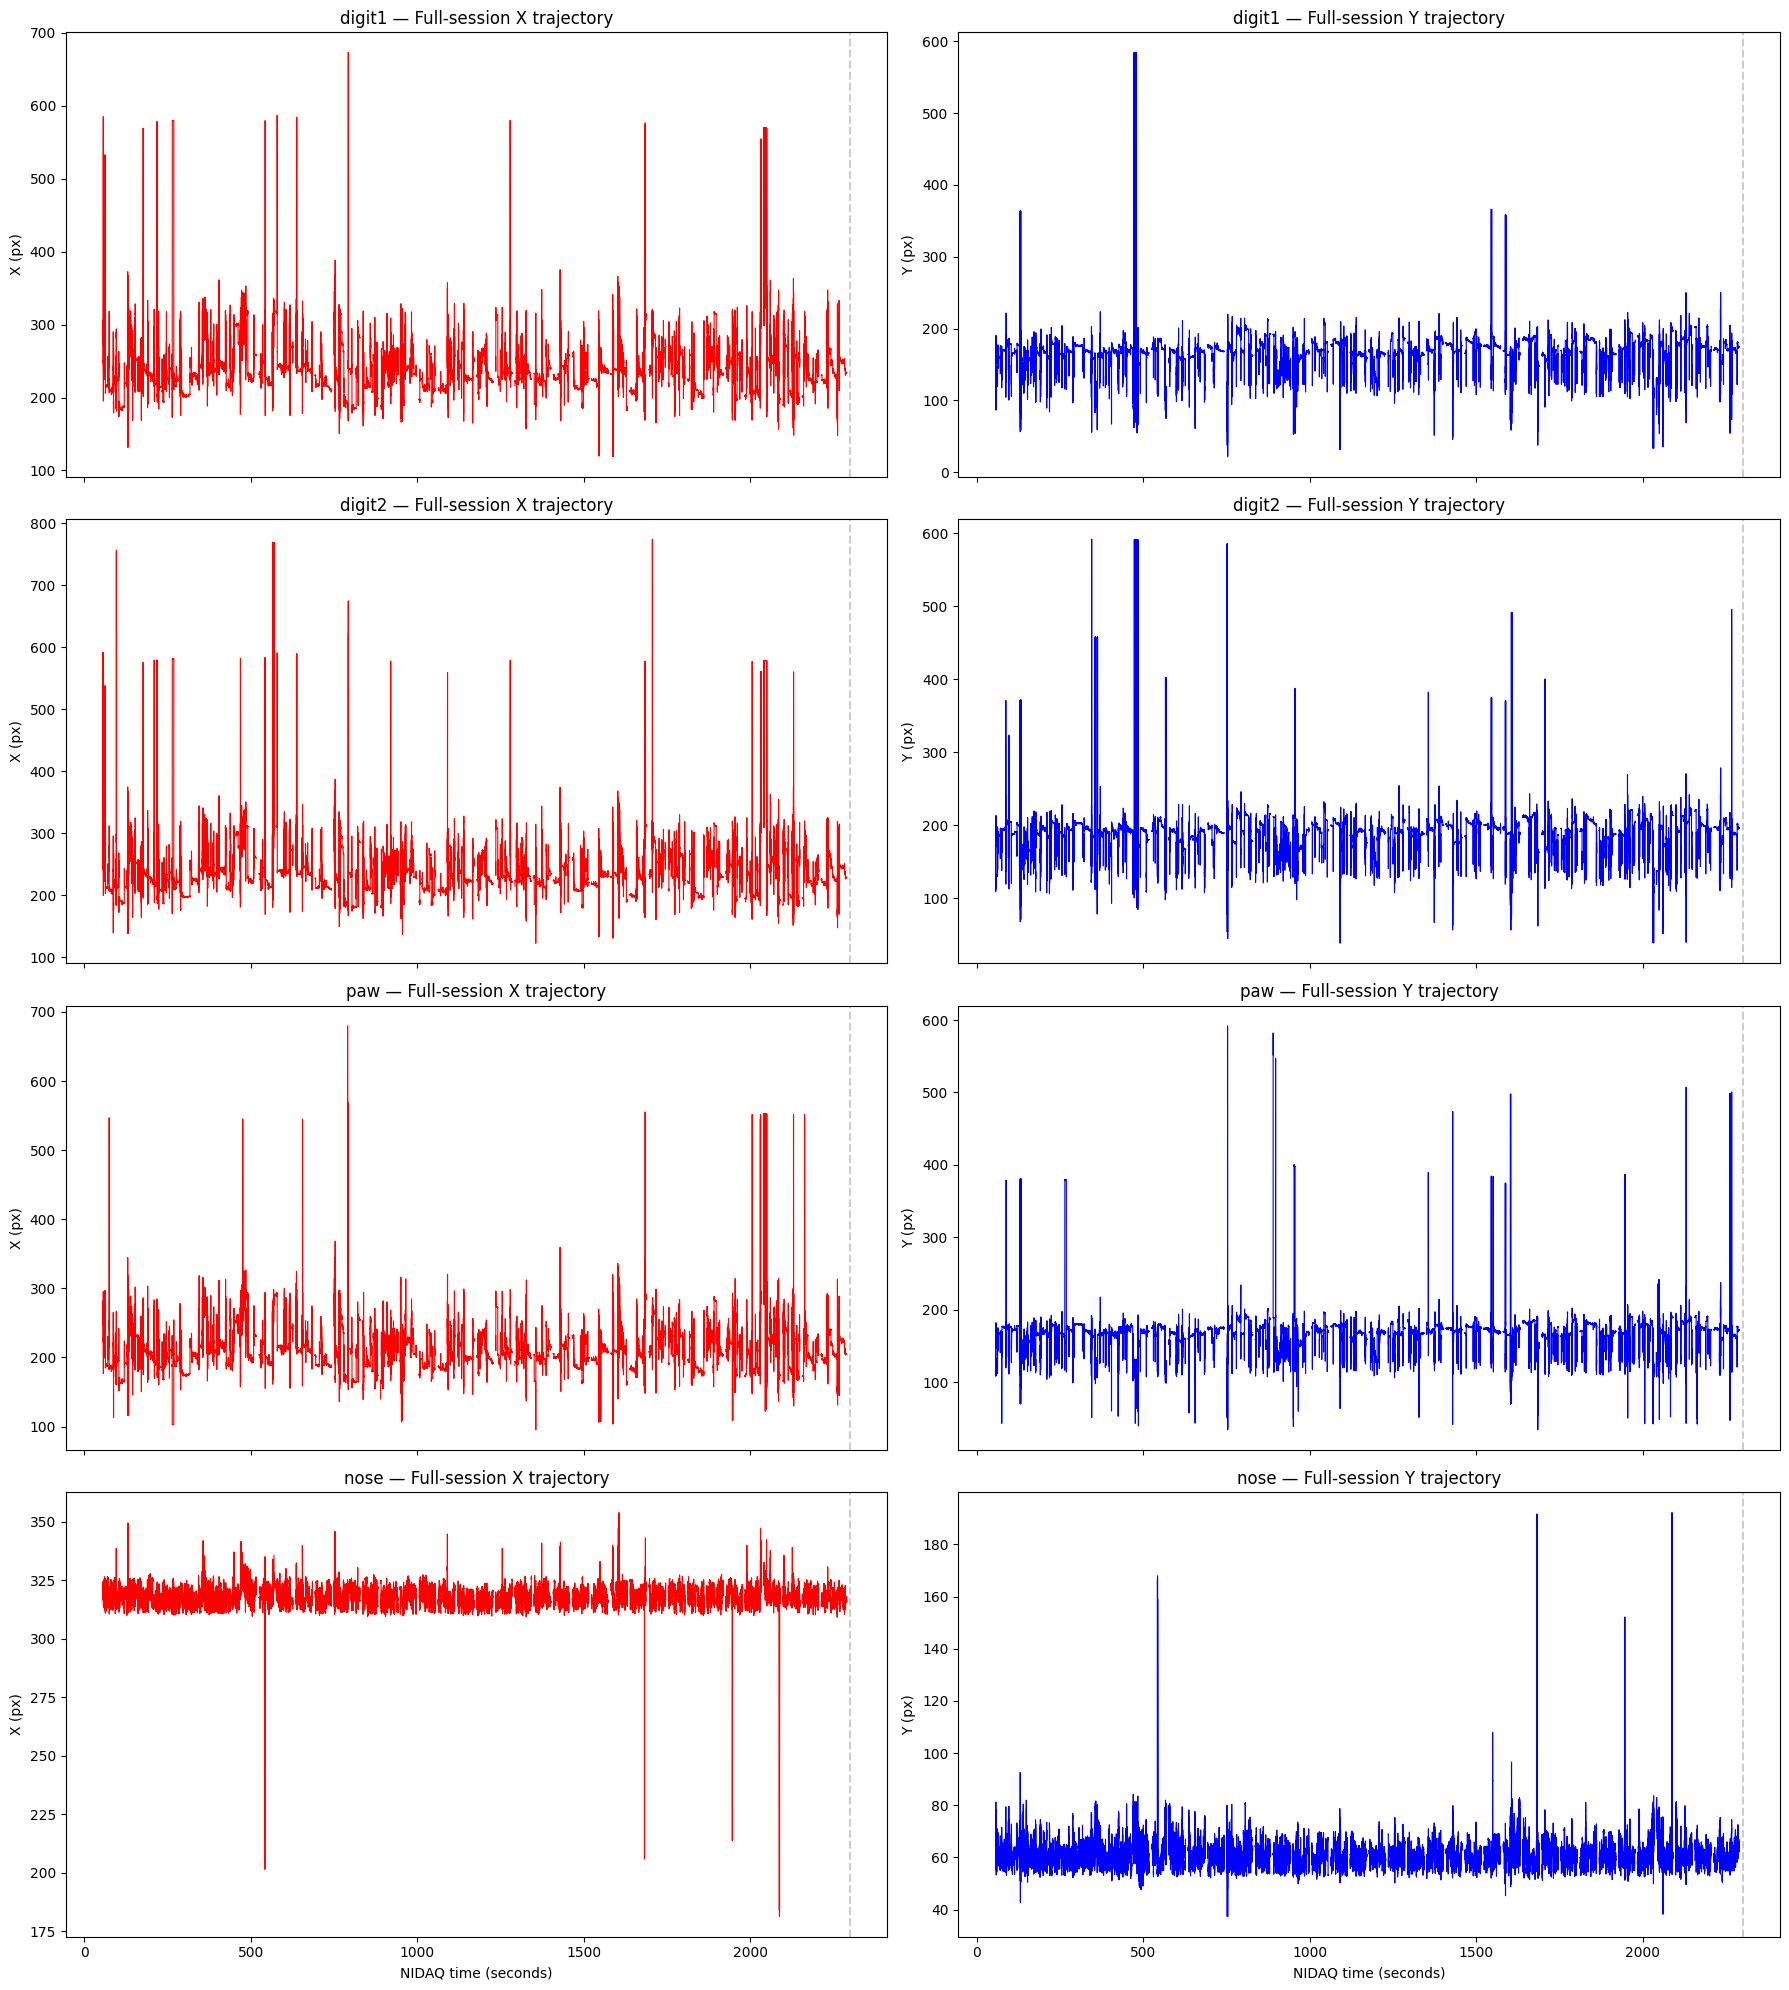


===== FULL-SESSION DLC TRAJECTORY PLOTTING COMPLETE =====

Saved DLC trajectory figure → G:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis\dlc_alignment\full_session_dlc_digit1_digit2_paw_nose.png


In [16]:
# ============================================================
# ========== CELL J — FULL-SESSION DLC TRAJECTORY PLOT =======
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print("\n===== Full-Session DLC Trajectory on NIDAQ Timeline =====")

# ------------------------------------------------------------
# SAFETY CHECKS
# ------------------------------------------------------------
required_vars = ["session", "analysis_folder"]
for v in required_vars:
    if v not in globals():
        raise RuntimeError(f"Variable '{v}' is missing. Run previous cells first.")

# ------------------------------------------------------------
# USER INPUT: list of bodyparts to plot
# ------------------------------------------------------------
bodyparts = ["digit1", "digit2", "paw", "nose"]   ########################################################################################################

# ------------------------------------------------------------
# 1. Load DLC column structure from block 0
# ------------------------------------------------------------
df0 = pd.read_hdf(session["blocks"][0]["dlc_path"])

column_map = {}

for bp in bodyparts:
    cols = [c for c in df0.columns if c[1] == bp]
    if len(cols) == 0:
        raise ValueError(f"Bodypart '{bp}' not found in DLC file.")

    x_col = [c for c in cols if c[2] == "x"][0]
    y_col = [c for c in cols if c[2] == "y"][0]
    lik_col = [c for c in cols if c[2] == "likelihood"][0]

    column_map[bp] = (x_col, y_col, lik_col)
    print(f"Using DLC columns for {bp}: {x_col}, {y_col}, {lik_col}")

# ------------------------------------------------------------
# 2. Build full-session arrays (PORTABLE)
# ------------------------------------------------------------
full_times = []
full_data = {bp: {"x": [], "y": []} for bp in bodyparts}
block_boundaries = []

for block_index, block in enumerate(session["blocks"]):

    ttl_times_block = np.array(block["ttl_times"])

    dlc_aligned_path = Path(block["dlc_aligned_path"])
    if not dlc_aligned_path.exists():
        raise FileNotFoundError(f"DLC-aligned file missing:\n{dlc_aligned_path}")

    dlc_aligned = np.load(dlc_aligned_path, allow_pickle=True)

    print(f"\n--- Block {block_index} ---")
    print(f"TTL pulses: {len(ttl_times_block)}")
    print(f"DLC-aligned loaded from: {dlc_aligned_path}")

    for bp in bodyparts:
        x_col, y_col, lik_col = column_map[bp]

        x_vals = []
        y_vals = []

        for row in dlc_aligned:
            if row is None:
                x_vals.append(np.nan)
                y_vals.append(np.nan)
            else:
                x_vals.append(row[x_col])
                y_vals.append(row[y_col])

        full_data[bp]["x"].extend(x_vals)
        full_data[bp]["y"].extend(y_vals)

    full_times.extend(ttl_times_block)
    block_boundaries.append(ttl_times_block[-1])

full_times = np.array(full_times)

for bp in bodyparts:
    full_data[bp]["x"] = np.array(full_data[bp]["x"])
    full_data[bp]["y"] = np.array(full_data[bp]["y"])

print("\nFull-session DLC arrays built successfully.")

# ------------------------------------------------------------
# 3. Plot full-session trajectories (one subplot per bodypart)
# ------------------------------------------------------------
fig, axes = plt.subplots(len(bodyparts), 2, figsize=(18, 5 * len(bodyparts)), sharex=True)

if len(bodyparts) == 1:
    axes = np.array([axes])

for row_idx, bp in enumerate(bodyparts):
    ax_x = axes[row_idx, 0]
    ax_y = axes[row_idx, 1]

    ax_x.plot(full_times, full_data[bp]["x"], color='red', linewidth=0.8)
    ax_x.set_ylabel("X (px)")
    ax_x.set_title(f"{bp} — Full-session X trajectory")

    ax_y.plot(full_times, full_data[bp]["y"], color='blue', linewidth=0.8)
    ax_y.set_ylabel("Y (px)")
    ax_y.set_title(f"{bp} — Full-session Y trajectory")

    for t in block_boundaries:
        ax_x.axvline(t, color='gray', linestyle='--', alpha=0.4)
        ax_y.axvline(t, color='gray', linestyle='--', alpha=0.4)

axes[-1, 0].set_xlabel("NIDAQ time (seconds)")
axes[-1, 1].set_xlabel("NIDAQ time (seconds)")

plt.tight_layout()
plt.show()

print("\n===== FULL-SESSION DLC TRAJECTORY PLOTTING COMPLETE =====\n")

# ------------------------------------------------------------
# 4. SAVE FIGURE TO ANALYSIS FOLDER (AUTO-INCREMENT)
# ------------------------------------------------------------
save_dir = analysis_folder / "dlc_alignment"
save_dir.mkdir(exist_ok=True)

bp_string = "_".join(bodyparts)
base_name = f"full_session_dlc_{bp_string}"
save_path = save_dir / f"{base_name}.png"

counter = 1
while save_path.exists():
    save_path = save_dir / f"{base_name}_{counter}.png"
    counter += 1

fig.savefig(save_path, dpi=300)
print(f"Saved DLC trajectory figure → {save_path}")



===== CELL K — DIAGNOSTIC MODE (NI‑RELATIVE SAFE) =====

Behavior TTL count: 71
Behavior TTL range (NI‑rel): 24.577 → 2410.707 s

DLC columns: X=('DLC_Resnet50_03042026_Cam2May5shuffle2_snapshot_best-40', 'paw', 'x'), Y=('DLC_Resnet50_03042026_Cam2May5shuffle2_snapshot_best-40', 'paw', 'y')
DLC file path: F:\Mouse1_030426-Kpk\03042026_Cam2-Kevin-2026-05-05\videos\04032026-1_cam2DLC_Resnet50_03042026_Cam2May5shuffle2_snapshot_best-40.h5

===== BLOCK-BY-BLOCK DLC DIAGNOSTICS =====

--- Block 0 ---
TTL count: 134517
TTL range (NI‑rel): 56.948 → 2299.994 s
DLC aligned path: G:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis\dlc_alignment\dlc_aligned_block0.npy
DLC aligned length: 134517
Missing DLC rows: 14249

===== FULL-SESSION DLC TIMELINE =====
DLC timeline length: 134517
DLC time range (NI‑rel): 56.948 → 2299.994 s
DLC NaN count: 14249

===== PHYSIOLOGY TIMELINE =====
Physiology duration (NI‑rel): 0 → 2435.476 s
Rate matrix shape: (100, 1

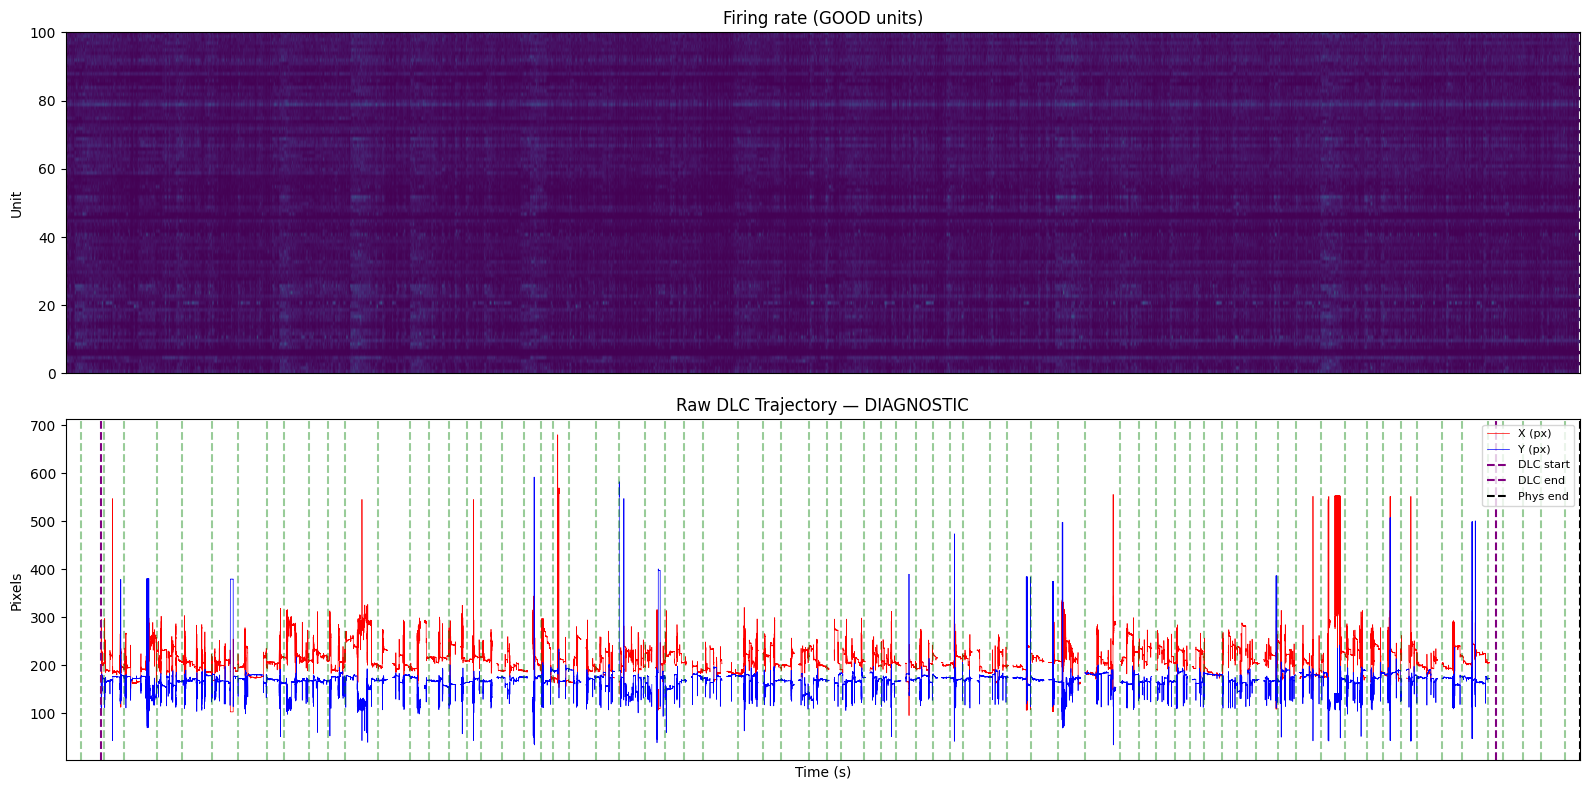


===== CELL K DIAGNOSTIC COMPLETE =====



In [17]:
# ============================================================
# ========== CELL K — RAW DLC + PHYSIOLOGY (DIAGNOSTIC) ======
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json

print("\n===== CELL K — DIAGNOSTIC MODE (NI‑RELATIVE SAFE) =====")

# ------------------------------------------------------------
# SAFETY CHECKS
# ------------------------------------------------------------
required_vars = ["session", "analysis_folder"]
for v in required_vars:
    if v not in globals():
        raise RuntimeError(f"Variable '{v}' is missing. Run previous cells first.")

# ------------------------------------------------------------
# USER PARAMETERS
# ------------------------------------------------------------
bodypart = "paw"
BEHAVIOR_PIN = 4
DRAW_LABELS = True
SHADE_AFTER_TTL = True
SHADE_WINDOW = 0.15
BEHAVIOR_HEIGHT = 2.0
HEATMAP_HEIGHT = 6.0

# ------------------------------------------------------------
# 0. LOAD BEHAVIORAL TTLs (NI‑RELATIVE)
# ------------------------------------------------------------
ttl_path = analysis_folder / "ttls" / f"TTL_Pin_{BEHAVIOR_PIN}.npy"
behavior_ttls = np.load(ttl_path)

print(f"\nBehavior TTL count: {len(behavior_ttls)}")
print(f"Behavior TTL range (NI‑rel): {behavior_ttls[0]:.3f} → {behavior_ttls[-1]:.3f} s")

# ------------------------------------------------------------
# 1. Load DLC column structure
# ------------------------------------------------------------
df0 = pd.read_hdf(session["blocks"][0]["dlc_path"])
cols = [c for c in df0.columns if c[1] == bodypart]
x_col = [c for c in cols if c[2] == "x"][0]
y_col = [c for c in cols if c[2] == "y"][0]

print(f"\nDLC columns: X={x_col}, Y={y_col}")
print(f"DLC file path: {session['blocks'][0]['dlc_path']}")

# ------------------------------------------------------------
# 2. Build full-session DLC trajectories (NI‑RELATIVE)
# ------------------------------------------------------------
full_times = []
full_x = []
full_y = []
block_boundaries = []

print("\n===== BLOCK-BY-BLOCK DLC DIAGNOSTICS =====")

for block_index, block in enumerate(session["blocks"]):

    ttl_times_block = np.array(block["ttl_times"])  # already NI‑relative
    dlc_aligned_path = Path(block["dlc_aligned_path"])
    dlc_aligned = np.load(dlc_aligned_path, allow_pickle=True)

    print(f"\n--- Block {block_index} ---")
    print(f"TTL count: {len(ttl_times_block)}")
    print(f"TTL range (NI‑rel): {ttl_times_block[0]:.3f} → {ttl_times_block[-1]:.3f} s")
    print(f"DLC aligned path: {dlc_aligned_path}")
    print(f"DLC aligned length: {len(dlc_aligned)}")
    print(f"Missing DLC rows: {sum(x is None for x in dlc_aligned)}")

    x_vals = []
    y_vals = []

    for row in dlc_aligned:
        if row is None:
            x_vals.append(np.nan)
            y_vals.append(np.nan)
        else:
            x_vals.append(row[x_col])
            y_vals.append(row[y_col])

    full_times.extend(ttl_times_block)
    full_x.extend(x_vals)
    full_y.extend(y_vals)
    block_boundaries.append(ttl_times_block[-1])

full_times = np.array(full_times)
full_x = np.array(full_x, float)
full_y = np.array(full_y, float)

print("\n===== FULL-SESSION DLC TIMELINE =====")
print(f"DLC timeline length: {len(full_times)}")
print(f"DLC time range (NI‑rel): {full_times[0]:.3f} → {full_times[-1]:.3f} s")
print(f"DLC NaN count: {np.sum(np.isnan(full_x))}")

# ------------------------------------------------------------
# 3. LOAD PHYSIOLOGY QC (NI‑RELATIVE)
# ------------------------------------------------------------
qc_dir = analysis_folder / "qc"
rate_matrix = np.load(qc_dir / "rate_matrix.npy")
good_units = np.load(qc_dir / "good_units.npy")

with open(qc_dir / "recording_duration.json", "r") as f:
    recording_duration = json.load(f)["recording_duration"]

print("\n===== PHYSIOLOGY TIMELINE =====")
print(f"Physiology duration (NI‑rel): 0 → {recording_duration:.3f} s")
print(f"Rate matrix shape: {rate_matrix.shape}")

# ------------------------------------------------------------
# 4. CROSS-TIMELINE DIAGNOSTICS
# ------------------------------------------------------------
print("\n===== CROSS-TIMELINE CHECK =====")
print(f"DLC end - Physiology end = {full_times[-1] - recording_duration:.3f} seconds")
print(f"Behavior TTL end - Physiology end = {behavior_ttls[-1] - recording_duration:.3f} seconds")

print("\nBlock boundaries (NI‑rel):")
for i, t in enumerate(block_boundaries):
    print(f"  Block {i} ends at {t:.3f} s")

# ------------------------------------------------------------
# 5. PLOT WITH AXIS OVERLAYS
# ------------------------------------------------------------
fig = plt.figure(figsize=(16, HEATMAP_HEIGHT + BEHAVIOR_HEIGHT))

# ---- Physiology heatmap ----
ax1 = fig.add_subplot(2, 1, 1)
ax1.imshow(
    rate_matrix,
    aspect='auto',
    extent=[0, recording_duration, 0, len(good_units)],
    origin='lower'
)
ax1.set_title("Firing rate (GOOD units)")
ax1.set_ylabel("Unit")
ax1.set_xticks([])

ax1.axvline(0, color='white', linestyle='--')
ax1.axvline(recording_duration, color='white', linestyle='--')

# ---- DLC trace ----
ax2 = fig.add_subplot(2, 1, 2, sharex=ax1)
ax2.plot(full_times, full_x, 'r', linewidth=0.5, label="X (px)")
ax2.plot(full_times, full_y, 'b', linewidth=0.5, label="Y (px)")

ax2.axvline(full_times[0], color='purple', linestyle='--', label="DLC start")
ax2.axvline(full_times[-1], color='purple', linestyle='--', label="DLC end")
ax2.axvline(recording_duration, color='black', linestyle='--', label="Phys end")

for t in behavior_ttls:
    ax2.axvline(t, color='green', linestyle='--', alpha=0.4)

ax2.set_ylabel("Pixels")
ax2.set_xlabel("Time (s)")
ax2.set_title("Raw DLC Trajectory — DIAGNOSTIC")
ax2.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

print("\n===== CELL K DIAGNOSTIC COMPLETE =====\n")



===== Peri-TTL Behavior + Physiology Zoom (NI-relative) =====
Found 71 behavioral TTLs on pin 4 (NI-relative)
Using first 10 TTLs for peri-event zooms.
TTL at 24.577s not inside any block — skipping.


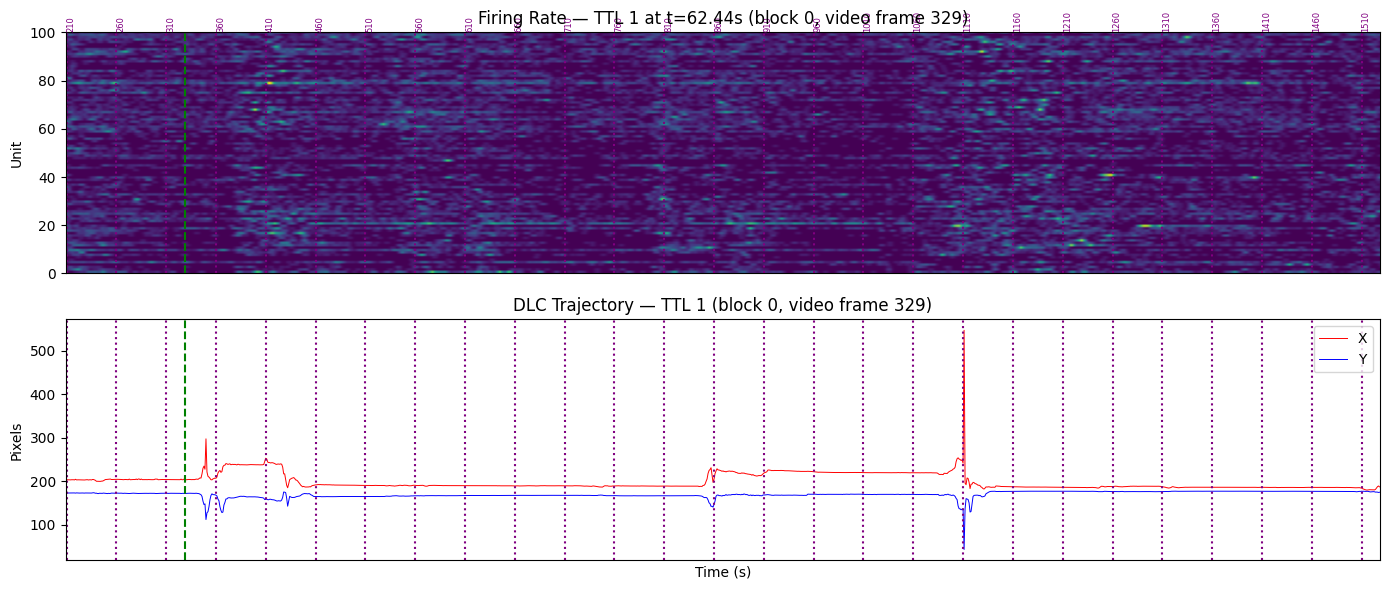

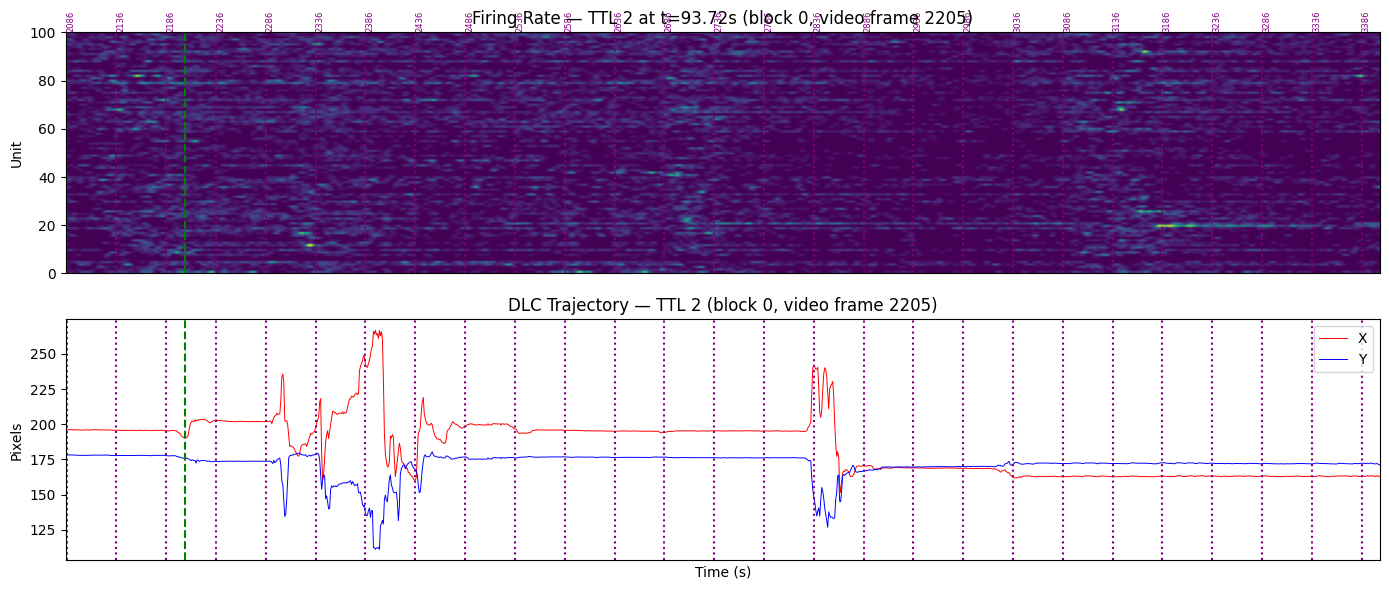

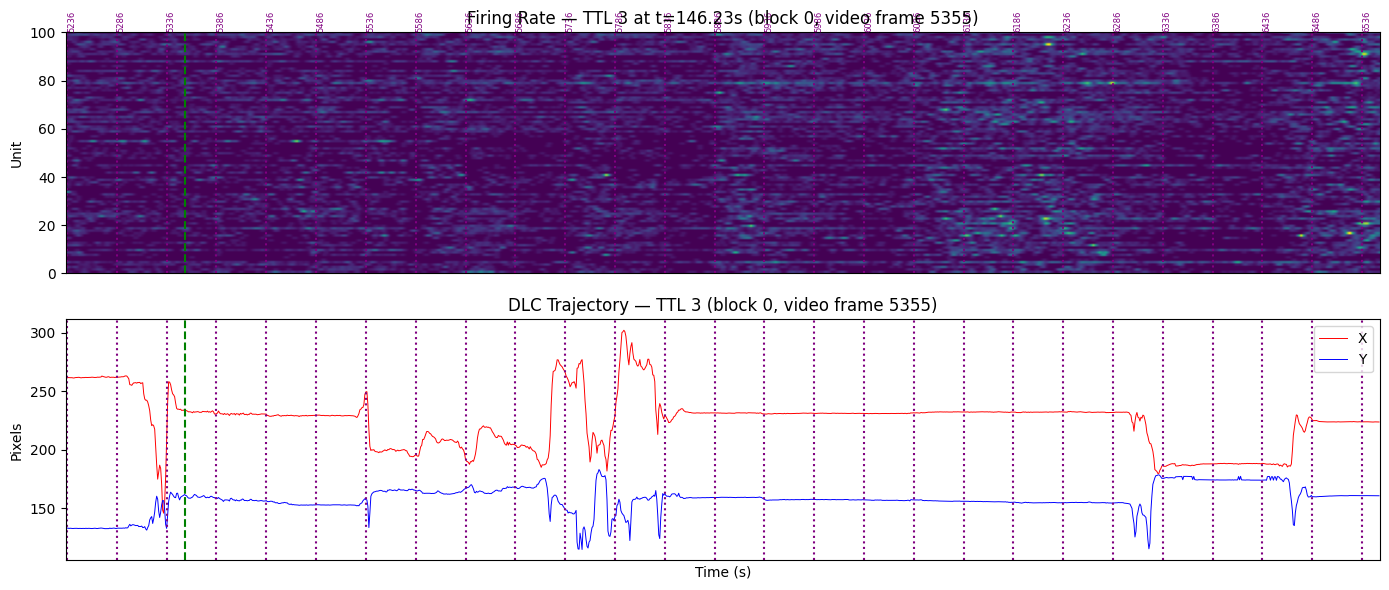

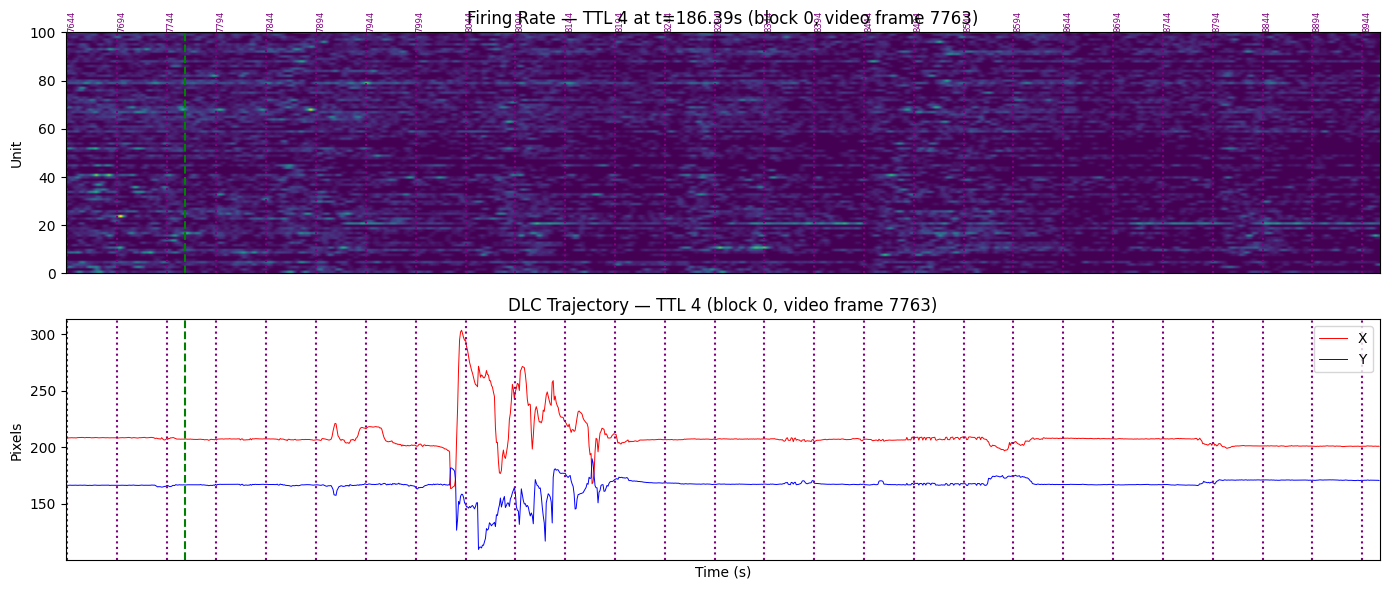

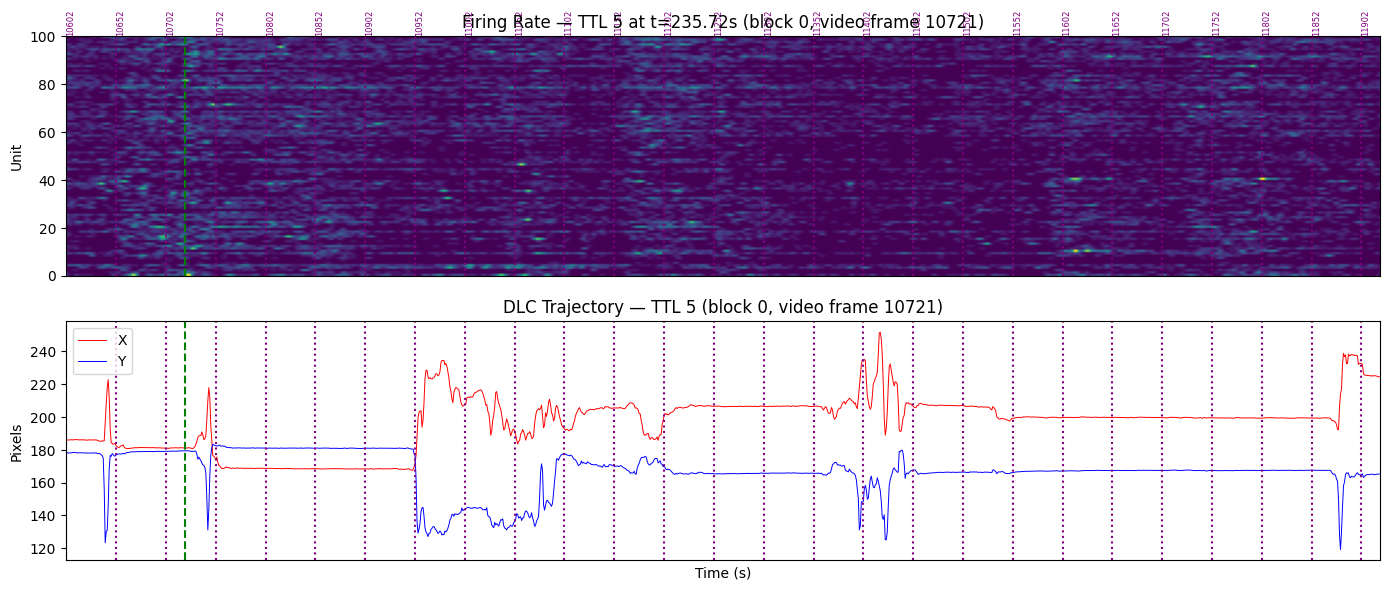

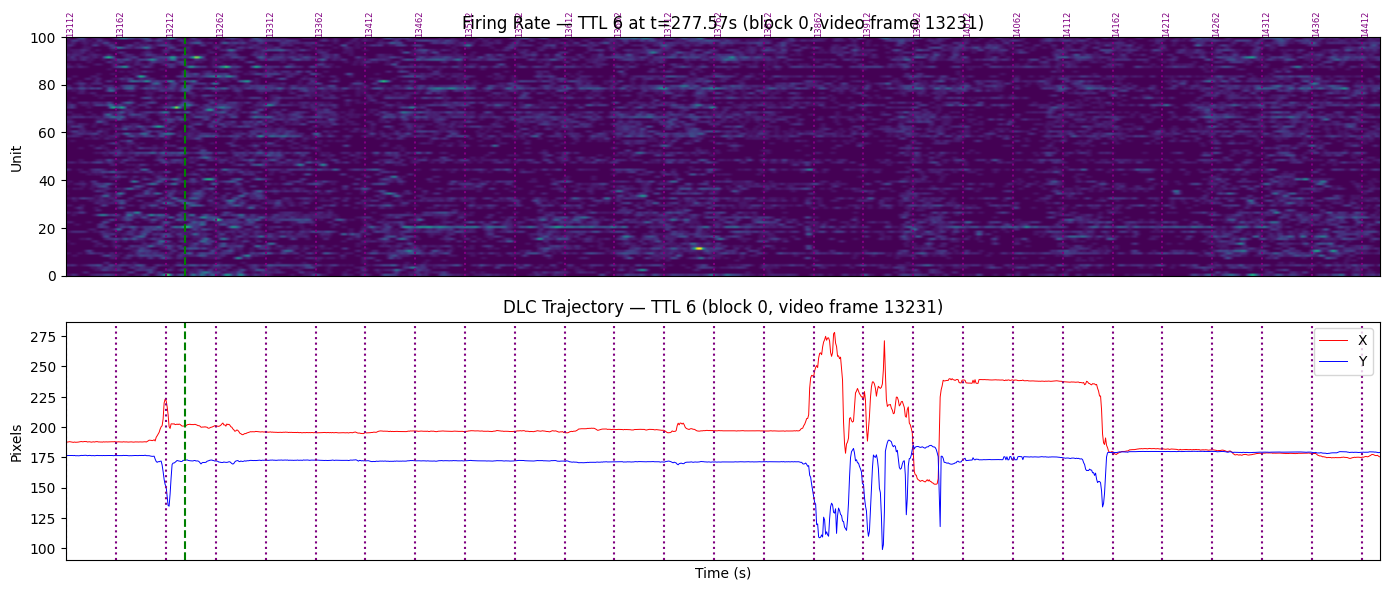

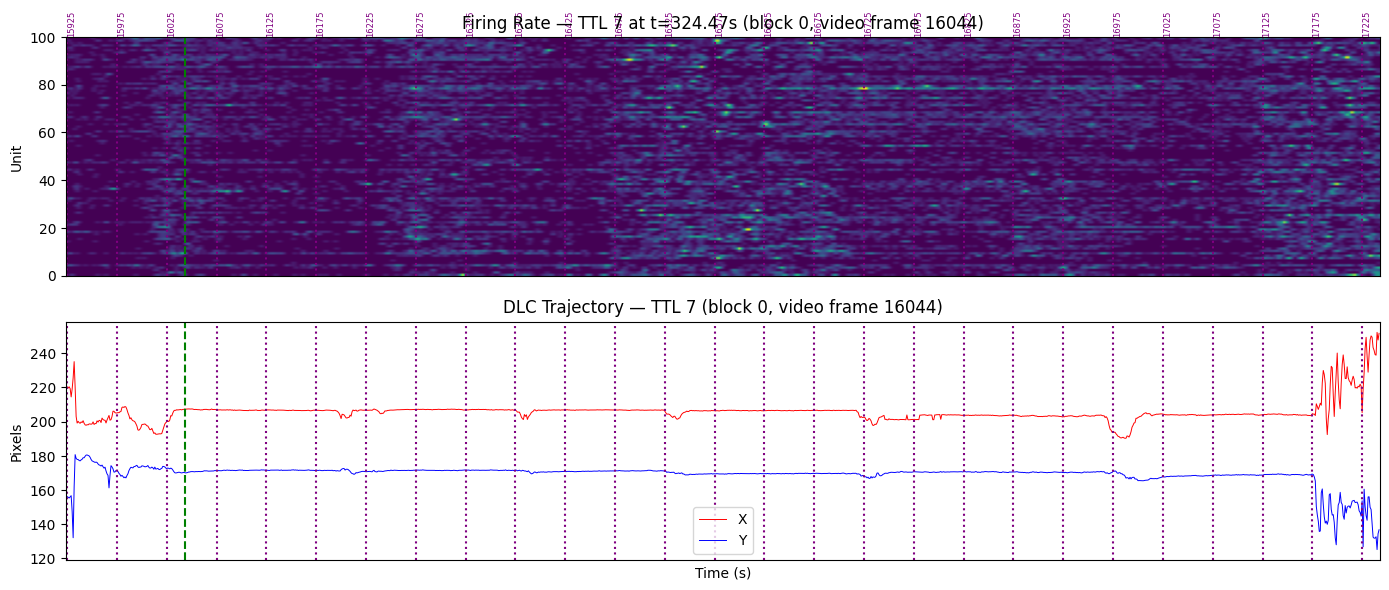

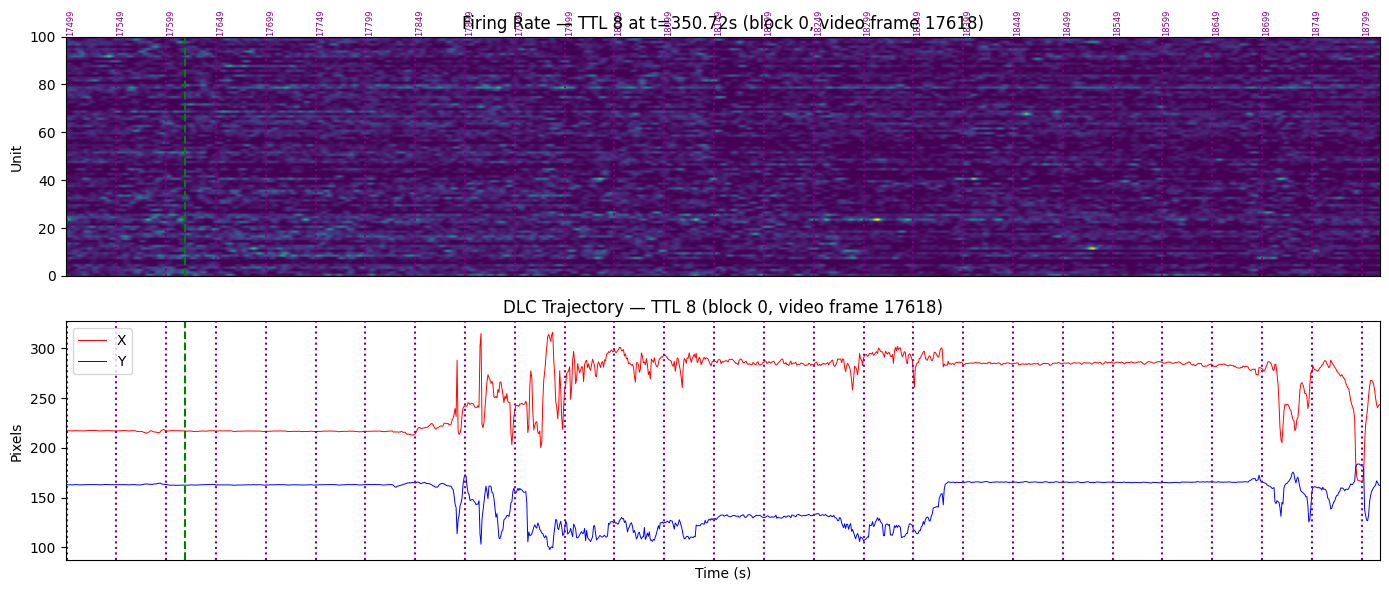

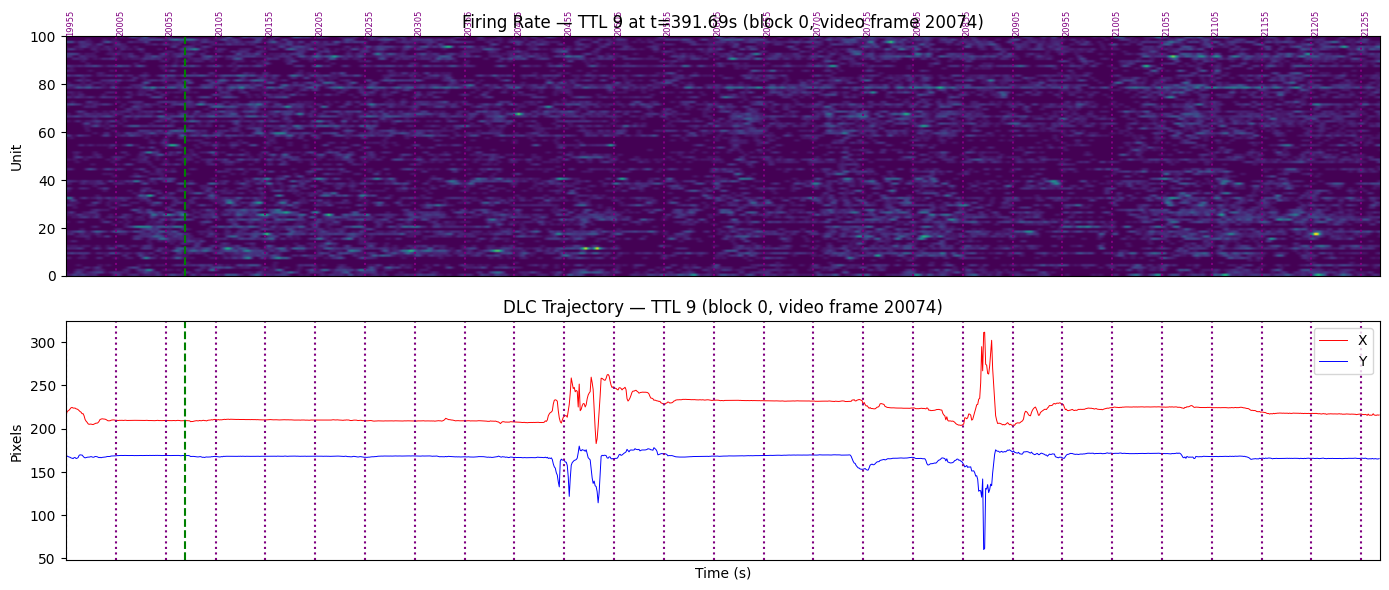


===== Peri-TTL Zoom Complete =====



In [18]:
# ============================================================
# ========== PERI-TTL ZOOM (NI-RELATIVE TIMEBASE) ============
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

print("\n===== Peri-TTL Behavior + Physiology Zoom (NI-relative) =====")

# ------------------------------------------------------------
# SAFETY CHECKS
# ------------------------------------------------------------
required_vars = [
    "analysis_folder", "session", "full_times", "full_x", "full_y",
    "rate_matrix", "good_units", "centers"
]
for v in required_vars:
    if v not in globals():
        raise RuntimeError(f"Variable '{v}' is missing. Run previous cells first.")

# ------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------
BEHAV_PIN = 4
WIN_PRE = 2.0
WIN_POST = 20.0
MAX_TTLS = 10
bodypart = "paw"

# ------------------------------------------------------------
# Helper: extract integer frame number from filename
# ------------------------------------------------------------
def extract_frame_number(fname):
    base = Path(fname).stem
    parts = base.split("_")
    return int(parts[1])

# ------------------------------------------------------------
# Load block metadata
# ------------------------------------------------------------
with open(analysis_folder / "metadata" / "block_info.json", "r") as f:
    block_info = json.load(f)

# Load aligned frames + TTLs for each block (NI-relative)
aligned_blocks = []
ttl_blocks = []

for b in range(len(block_info)):
    aligned_blocks.append(
        np.load(analysis_folder / "camera_alignment" / f"aligned_frames_block{b}.npy",
                allow_pickle=True)
    )
    ttl_blocks.append(
        np.load(analysis_folder / "camera_alignment" / f"ttl_times_block{b}.npy")
    )

# ------------------------------------------------------------
# Load behavioral TTLs (NI-relative, from disk)
# ------------------------------------------------------------
beh_ttls_path = analysis_folder / "ttls" / f"TTL_Pin_{BEHAV_PIN}.npy"
beh_ttles = np.load(beh_ttls_path)

print(f"Found {len(beh_ttles)} behavioral TTLs on pin {BEHAV_PIN} (NI-relative)")
if MAX_TTLS is not None:
    beh_ttles = beh_ttles[:MAX_TTLS]
    print(f"Using first {len(beh_ttles)} TTLs for peri-event zooms.")

# ------------------------------------------------------------
# Loop through behavioral TTLs
# ------------------------------------------------------------
for idx, t_event in enumerate(beh_ttles):

    # --------------------------------------------------------
    # Determine which block this TTL belongs to (NI-relative)
    # --------------------------------------------------------
    block_id = None
    ttl_idx_in_block = None

    for b, info in enumerate(block_info):
        start = info["start_time_sec"]   # NI-relative
        end   = info["end_time_sec"]     # NI-relative
        if start <= t_event <= end:
            block_id = b
            ttl_idx_in_block = np.argmin(np.abs(ttl_blocks[b] - t_event))
            break

    if block_id is None:
        print(f"TTL at {t_event:.3f}s not inside any block — skipping.")
        continue

    # --------------------------------------------------------
    # Get aligned frame filename for this TTL
    # --------------------------------------------------------
    aligned_frames = aligned_blocks[block_id]
    fname = aligned_frames[ttl_idx_in_block]

    if fname is None:
        print(f"TTL {idx}: missing aligned frame — skipping.")
        continue

    video_frame = extract_frame_number(fname)

    # --------------------------------------------------------
    # Build 50-frame tick marks across the entire window
    # --------------------------------------------------------
    frame_intervals = np.diff(ttl_blocks[block_id])
    est_fps = 1 / np.median(frame_intervals)

    frames_before = int(WIN_PRE * est_fps)
    frames_after  = int(WIN_POST * est_fps)

    tick_frames = np.arange(video_frame - frames_before,
                            video_frame + frames_after + 1,
                            50)
    tick_frames = tick_frames[tick_frames >= 0]

    tick_times = []
    for vf in tick_frames:
        matches = [
            i for i, f in enumerate(aligned_frames)
            if f is not None and extract_frame_number(f) == vf
        ]
        if len(matches) > 0:
            tick_times.append(ttl_blocks[block_id][matches[0]])

    tick_times = np.array(tick_times)

    # --------------------------------------------------------
    # Build peri-event window (NI-relative)
    # --------------------------------------------------------
    t0 = t_event - WIN_PRE
    t1 = t_event + WIN_POST

    mask_dlc = (full_times >= t0) & (full_times <= t1)
    mask_fr  = (centers >= t0) & (centers <= t1)

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------
    fig = plt.figure(figsize=(14, 6))

    # ---- Firing rate ----
    ax1 = fig.add_subplot(2, 1, 1)
    ax1.imshow(
        rate_matrix[:, mask_fr],
        aspect='auto',
        extent=[t0, t1, 0, len(good_units)],
        origin='lower'
    )

    ax1.axvline(t_event, color='green', linestyle='--')

    for tf, vf in zip(tick_times, tick_frames):
        ax1.axvline(tf, color='purple', linestyle=':')
        ax1.text(tf, len(good_units) + 1, f"{vf}", rotation=90,
                 fontsize=6, color='purple')

    ax1.set_title(
        f"Firing Rate — TTL {idx} at t={t_event:.2f}s "
        f"(block {block_id}, video frame {video_frame})"
    )
    ax1.set_ylabel("Unit")
    ax1.set_xticks([])

    # ---- DLC ----
    ax2 = fig.add_subplot(2, 1, 2, sharex=ax1)

    ax2.plot(full_times[mask_dlc], full_x[mask_dlc], 'r', linewidth=0.7, label="X")
    ax2.plot(full_times[mask_dlc], full_y[mask_dlc], 'b', linewidth=0.7, label="Y")

    ax2.axvline(t_event, color='green', linestyle='--')

    for tf in tick_times:
        ax2.axvline(tf, color='purple', linestyle=':')

    ax2.set_ylabel("Pixels")
    ax2.set_xlabel("Time (s)")
    ax2.set_title(
        f"DLC Trajectory — TTL {idx} "
        f"(block {block_id}, video frame {video_frame})"
    )
    ax2.legend()

    plt.tight_layout()
    plt.show()

print("\n===== Peri-TTL Zoom Complete =====\n")
